# Final Homework — Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | Final Homework |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Head lecturer** | Dr. Uri Itai |
| **Teaching assistant** | Hanit Hadad Ohayon |
| **Grader** | Dror Meirovich |
| **Submission deadline** | 18.09.2026 |

---

## Table of Contents

0. [Introduction](#0-introduction)
1. [Dataset Selection](#1-dataset-selection)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Dimensionality Reduction (PCA)](#3-dimensionality-reduction-pca)
4. [Clustering Analysis](#4-clustering-analysis)
5. [Multi-Dimensional Anomaly Detection](#5-multi-dimensional-anomaly-detection)
6. [Comparison of Anomaly Detection Methods](#6-comparison-of-anomaly-detection-methods)
7. [Critical Analysis and Reflection](#7-critical-analysis-and-reflection)
8. [Ethical Considerations](#8-ethical-considerations)
9. [Final Visualization Dashboard](#9-final-visualization-dashboard-optional)

## 0. Introduction

This chapter states the objective, the stance the analysis takes towards its own
results, and the methodology. It contains no code and no results; the analysis
begins in chapter 1.

### 0.1 Objective

The assignment sets out to explore the structure of a real-world dataset using
unsupervised methods: clustering, dimensionality reduction, and multi-dimensional
anomaly detection. No labels guide any part of it.

Its framing matters more than its component list. The assignment opens by
observing that unsupervised problems are **fundamentally ill-defined**: nothing
tells us how many clusters should exist, which observations are anomalous, or
whether meaningful clusters and anomalies exist at all. Different methods,
distance measures and parameter choices can lead to different conclusions, and
more than one may be reasonable.

Two consequences follow, and they govern how this notebook is written.

**First, the goal is not to produce output.** The assignment states plainly that
it does not grade "beautiful" clusters. It grades understanding of what the
methods assume, why they disagree, and what their results mean for the data.
Every algorithm applied here is therefore accompanied by its mathematical
intuition, its assumptions, and an account of where those assumptions fail on
this dataset.

**Second, a negative result is a legitimate result.** The assignment states
explicitly that an inability to find meaningful clusters, significant anomalies
or effective dimensionality reduction does not indicate poor analysis — the
structure may simply not be there. This notebook therefore commits in advance to
reporting weak or absent structure where that is what the evidence shows, rather
than selecting the parameters that produce the most attractive picture. Where
methods disagree, the disagreement is reported and examined rather than resolved
by preference.

### 0.2 Methodology

Each analytical section follows the same four-part pattern:

- **Method** — what is being done and why.
- **Results** — the actual numerical and visual output.
- **Interpretation** — what the results mean, including where they contradict
  what was expected.
- **Conclusion** — the single insight the section establishes.

Interpretations are written **after** the results have been read, never drafted
in advance. Where the data shows a pattern but cannot establish its cause, the
proposed cause is labelled as a hypothesis and the evidence that would test it is
named. Claims about what an algorithm "found" are kept separate from claims about
what is true of the games themselves.

The analysis proceeds in the order the assignment specifies: the dataset and its
provenance, exploratory analysis, PCA, clustering of both samples and features,
the three required anomaly detection methods, their comparison, critical
reflection, and ethical considerations.

### 0.3 What the Assignment Requires and What Is Chosen Here

The assignment fixes the analytical programme but leaves the material open. Kept
distinct throughout:

**Required by the assignment** — the five dataset selection criteria and the
provenance description; the exploratory, PCA, clustering, anomaly-detection,
comparison, reflection and ethics sections with their listed contents; at least
three clustering methods; clustering of the feature space as well as the samples;
all three anomaly detection methods; mathematical intuition for each method.

**Chosen here, and justified where it appears** — the dataset; which eight
features form the numeric matrix and which columns are held back; the log
transform applied to the heavy-tailed features; which three clustering algorithms
are used; how every hyperparameter is selected; and which evaluation metrics are
reported beyond the one the assignment names.

No choice in the second list is presented as though it came from the first.

## 1. Dataset Selection

**Method.** This chapter identifies the dataset, verifies it against the five
selection criteria, records what the source does and does not document, defines
every feature used, states which columns were excluded and why, and sets out the
limitations that constrain everything the later chapters can claim.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# The helper package for this assignment sits one level above the notebook and
# adds Assignment 1's package to the path, so the cleaning and the derived
# features defined there are reused unchanged rather than reimplemented.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from unsupervised.data_setup import (
    ANNOTATION_VARIABLES,
    LOG_TRANSFORMED_FEATURES,
    MODEL_FEATURES,
    NEW_FEATURES,
    ORIGINAL_FEATURES,
    PRIOR_ENGINEERED_FEATURES,
    SNAPSHOT_DATE,
    build_matrix,
    describe_feature_provenance,
    describe_source_file,
    load_analysis_frame,
    summarise_excluded_candidates,
    verify_selection_requirements,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

games = load_analysis_frame()
print(f"Rows loaded: {len(games):,}")

Rows loaded: 1,500


### 1.1 Source and Provenance

The dataset is the one used in Assignments 1 and 2, which the assignment
explicitly permits. It records the 1,500 highest-revenue games released on Steam
during 2024.

In [2]:
describe_source_file()

,Value
Property,
File,Steam_2024_bestRevenue_1500.csv
Size,"180,690 bytes (176.5 KB)"
Distributed via,"Kaggle, user 'alicemtopcu'"
Dataset URL,https://www.kaggle.com/datasets/alicemtopcu/top-1500-games-on-steam-by-revenue-09-09-2024
Extraction date,"2024-09-09, stated in the dataset title"
Why it was collected,Not specified by the source
Who originally collected it,Not specified by the source
Licence,Not recorded in the downloaded file
Methodology note,None supplied with the file


**Where the dataset comes from.** It was downloaded from Kaggle, from the dataset
*Top 1500 Games on Steam by Revenue (09-09-2024)*, published by the user
`alicemtopcu`. The extraction date of 9 September 2024 is stated in the dataset's
own title, and Assignment 1 corroborated it independently: the file's creation
timestamp is 11 September 2024, two days later, which is what a download delay
looks like.

**Why it was collected — not specified by the source.** The Kaggle page carries
no statement of purpose, and no datasheet, methodology note or licence file
accompanies the download. Nothing in the file records why it was assembled. The
field selection is consistent with commercial market intelligence rather than
research, but that is an inference from the shape of the data and is not
documented anywhere, so it is recorded as such rather than asserted.

**Who collected it — not specified by the source.** The Kaggle account is the
*distributor*, and a distributor is not necessarily the collector. The originating
producer is not named on the dataset page or in the file.

One fact bears on this and is verifiable independently: **Valve publishes no
per-title sales or revenue figures for Steam.** No public interface exposes how
many copies a game has sold. It follows that `revenue` and `copiesSold` cannot be
direct measurements and must be estimates produced by some third-party model.
Assignment 2 established the point quantitatively — regressing log revenue on log
copies and log price returned coefficients of 0.988 and 1.005 with an R² of
0.9901, recovering an accounting identity almost exactly. **Which** estimator
produced them, and with what error, is not stated. This is the single most
important property of the dataset for an anomaly-detection assignment, and
section 1.5 returns to it.

### 1.2 Verification Against the Selection Criteria

The assignment lists five criteria a dataset must satisfy. They are checked in
code rather than asserted.

In [3]:
verify_selection_requirements(games)

,Required,Observed,Status
Requirement,,,
"At least 1,000 rows",">= 1,000","1,500",PASS
At least 8 features,>= 8,"9 in the source file, excluding 2 identifiers; 8 used for modelling",PASS
Mostly numerical variables,majority numeric,5 of 9 source features are numeric; the modelling matrix is 8/8 numeric,PASS
Real-world dataset,yes,"Commercially released Steam titles, published on Kaggle",PASS
No pre-labeled anomaly column,none present,"No column encodes an outlier, anomaly or class label",PASS


**Results and interpretation.** All five criteria are satisfied, though two
deserve a precise reading rather than a tick.

**"At least 8 features."** The source file has 11 columns, two of which — `name`
and `steamId` — are identifiers with 1,500 distinct values apiece and carry no
distributional information. Excluding them leaves **9 analysable features**, above
the minimum. The numeric matrix built in section 1.3 uses **8** of them.

**"Mostly numerical variables."** Of the 9 analysable source features, **5 are
numeric** — a majority, so the criterion holds, but only just. This is the
dataset's weakest point against the assignment, since PCA, distance-based
clustering and multi-dimensional anomaly detection all operate on numeric
matrices. Section 1.3 sets out how a matrix of eight numeric features is obtained
without inventing anything for the purpose.

**"No pre-labeled anomaly column."** No column in the file encodes an outlier,
anomaly, or class label of any kind. Nothing in the analysis that follows has
access to a ground truth, which is the condition the assignment intends.

### 1.3 The Analysis Matrix, and Where Each Feature Came From

**Method.** A concern applies to any dataset that only narrowly meets a feature
count: features can always be manufactured to satisfy it, and manufactured
features distort exactly the analyses this assignment performs. Ratios of
existing columns create collinearity that PCA then reports as redundancy;
duplicate encodings of one variable create correlations that clustering then
reports as structure.

Each feature is therefore classified by origin, and the count is checked against
the requirement **without** any feature created for this assignment.

In [4]:
print(f"Original dataset columns                     : {len(ORIGINAL_FEATURES)}  {ORIGINAL_FEATURES}")
print(f"Engineered in Assignment 1, reused in A2     : {len(PRIOR_ENGINEERED_FEATURES)}  {PRIOR_ENGINEERED_FEATURES}")
print(f"Newly created for this assignment            : {len(NEW_FEATURES)}  {NEW_FEATURES or '[]'}")
print()
print(f"Modelling matrix                             : {len(MODEL_FEATURES)} features")
print(f"Minimum required by the assignment           : 8")
print(f"Requirement met without any new feature      : {len(ORIGINAL_FEATURES) + len(PRIOR_ENGINEERED_FEATURES) >= 8}")

display(describe_feature_provenance())

Original dataset columns                     : 5  ['copiesSold', 'price', 'revenue', 'avgPlaytime', 'reviewScore']
Engineered in Assignment 1, reused in A2     : 3  ['daysOnSale', 'publisherReleaseCount', 'selfPublished']
Newly created for this assignment            : 0  []

Modelling matrix                             : 8 features
Minimum required by the assignment           : 8
Requirement met without any new feature      : True


,Provenance,Meaning,Unit
Feature,,,
copiesSold,Original column,Estimated lifetime units sold at the snapshot date,count
price,Original column,Listed store price; zero denotes a free-to-play title,USD (currency not stated by the source; inferred)
revenue,Original column,Estimated lifetime gross revenue at the snapshot date,USD (currency and gross/net basis not stated; inferred)
avgPlaytime,Original column,Average time played per owner,hours (unit not stated; inferred from the observed range)
reviewScore,Original column,"Share of user reviews that are positive; 0 is a placeholder, not a score","percent, 0-100 (definition not stated; inferred)"
daysOnSale,Engineered in Assignment 1,"Days between release and the 2024-09-09 snapshot, i.e. exposure",days
publisherReleaseCount,Engineered in Assignment 1,Titles in this dataset by the most prolific publisher credited on the game,count
selfPublished,Engineered in Assignment 1,"1 when the publisher and developer strings match, 0 otherwise",binary


**Interpretation — what each feature represents.** The table above gives the
meaning and unit of all eight. Three points are worth drawing out.

**Five features are original columns** and three were derived in Assignment 1 and
reused unchanged in Assignment 2. **No feature was created for this assignment.**
The eight-feature minimum is met by 5 + 3 = 8, so nothing was engineered to reach
the threshold.

**Several units are inferred rather than documented.** The source states no
currency for `price` and `revenue`, no unit for `avgPlaytime`, and no definition
for `reviewScore`. USD, hours and percent-positive are the only readings
consistent with the observed ranges, but they are inferences. An undocumented
unit is a limitation of the data, and marking it visibly is more honest than
silently adopting the obvious guess.

**Two features are not continuous measurements**, which matters for methods that
assume continuity:

- `selfPublished` is **binary**. It is a legitimate feature — Assignment 1 found
  publisher and developer identical for roughly half the catalogue — but a
  balanced binary variable cannot produce a large standardised deviation, so it
  can never contribute to a Z-score anomaly. Section 5.1 measures this directly.
  It also carries full weight in Euclidean distance once standardised, so it
  influences clustering considerably. That is a property of the **representation**
  chosen, not of any tuning parameter, and section 4 examines it under that
  heading.
- `publisherReleaseCount` is a **count computed within this dataset**. Because
  the dataset was selected on revenue, a studio appears often partly because
  several of its titles earned well, so the feature carries a faint trace of the
  selection. Assignment 2 measured its rank correlation with log revenue at 0.12.

In [5]:
summarise_excluded_candidates()

,Would have been,Reason for exclusion
Column,,
publisherTier,Would have been new for this assignment,Ordinal encoding of plotClass. Excluded on evidence: a Z-score on it flags exactly the 52 AAA ti...
releaseMonth,Would have been new for this assignment,Correlates -0.99 with daysOnSale because both derive from releaseDate. Including both would crea...
"revenuePerCopy, revenuePerDay, priceRealisation",Engineered in Assignment 1,"Algebraic functions of features already in the matrix, so they would manufacture collinearity ra..."
"name, steamId",Original columns,"Identifiers with 1,500 distinct values; carry no distributional signal."
"publishers, developers",Original columns,"Free-text with 1,131 and 1,406 distinct values; not numeric and not encodable at this cardinalit..."
"plotClass, priceBand, isFreeToPlay",Engineered in Assignment 1,Categorical. Held back as annotations used to interpret and validate the clusters and anomalies ...


**Interpretation — what was excluded, and why.** Two exclusions were decided on
measured evidence rather than preference, and both would have corrupted later
chapters had they been kept.

**`publisherTier`** — an ordinal encoding of studio scale (Indie < AA < AAA) —
was the only candidate that would have been newly created here. It was rejected
on three independent grounds. A Z-score computed on it flags exactly the 52 AAA
titles, which would convert a **studio label into a statistical anomaly** and
contaminate chapter 5. It raises the number of components needed for 90% of
variance from six to seven, adding a dimension without adding structure. And it
lowers the k = 3 silhouette from 0.195 to 0.181. Encoding three categories
as 0, 1, 2 also imposes an arbitrary claim that the step
from Indie to AA equals the step from AA to AAA, which directly distorts every
distance computed from it. `plotClass` is therefore retained as an **annotation**:
it is used to interpret and validate the clusters and anomalies that the methods
find, which is more informative than burying it inside a distance metric.

**`releaseMonth`** correlates **−0.99** with `daysOnSale`, because both are
functions of the release date under a fixed snapshot. Including both would have
placed a near-duplicate pair in the matrix, and PCA would then have reported the
resulting redundancy as a finding about the data rather than an artefact of the
feature set.

The three ratio features from Assignment 1 — `revenuePerCopy`, `revenuePerDay`
and `priceRealisation` — are algebraic functions of columns already present and
were excluded for the same reason.

In [6]:
analysis_matrix = build_matrix(games, log_transform=False)

print(f"Matrix shape                : {analysis_matrix.shape[0]:,} x {analysis_matrix.shape[1]}")
print(f"All columns numeric         : {analysis_matrix.dtypes.apply(lambda d: d.kind in 'ifb').all()}")
print(f"Duplicate rows              : {analysis_matrix.duplicated().sum()}")
print(f"Constant columns            : {[c for c in analysis_matrix if analysis_matrix[c].nunique() <= 1] or 'none'}")
print()
print("Missing values (placeholders converted by the Assignment 1 cleaning):")
print(analysis_matrix.isna().sum().loc[lambda counts: counts > 0].to_string())
print()
print(f"Annotation variables held out of the matrix : {ANNOTATION_VARIABLES}")
print(f"Heavy-tailed features to be log-transformed : {LOG_TRANSFORMED_FEATURES}")
print(f"Snapshot date used for daysOnSale           : {SNAPSHOT_DATE:%Y-%m-%d}")

Matrix shape                : 1,500 x 8
All columns numeric         : True
Duplicate rows              : 0
Constant columns            : none

Missing values (placeholders converted by the Assignment 1 cleaning):
avgPlaytime     1
reviewScore    99

Annotation variables held out of the matrix : ['name', 'steamId', 'plotClass', 'priceBand', 'isFreeToPlay']
Heavy-tailed features to be log-transformed : ['copiesSold', 'revenue', 'avgPlaytime', 'publisherReleaseCount']
Snapshot date used for daysOnSale           : 2024-09-09


**Results.** The matrix is 1,500 × 8, fully numeric, with no duplicate rows and
no constant columns. Two features carry missing values — 99 in `reviewScore` and
one in `avgPlaytime` — and both are the placeholder zeros identified in Assignment
1, converted to missing values by the cleaning imported from it rather than left
in as scores of zero. Leaving them would have created a spurious group of 99
identical-looking games that every clustering and anomaly method would then have
reported as structure. Imputation is deferred to the point of use so that each
method's sensitivity to it can be examined.

### 1.4 Annotation Variables

Three categorical columns are deliberately excluded from the numeric matrix and
retained for interpretation: `plotClass` (studio scale), `priceBand`, and
`isFreeToPlay`. Together with `name` they allow a cluster or a flagged anomaly to
be described in terms a reader can recognise — "this cluster is mostly cheap indie
titles", "this anomaly is a free-to-play game" — without those descriptions having
influenced the geometry that produced them.

This separation is what makes the later validation meaningful. If clusters
discovered from eight numeric features turn out to align with studio scale, that
is evidence the structure is real, precisely because studio scale was not
available to the algorithm.

### 1.5 Limitations and Biases

**Method.** The assignment requires possible limitations and biases to be stated.
Four apply here, and each constrains what later chapters may legitimately claim.

**1. Survivorship: the sample is selected on the quantity of greatest interest.**
These are the 1,500 highest-earning games of 2024. They are not a sample of games
on Steam; they are its commercial upper tail. Every statement about distributions,
clusters or anomalies in this notebook therefore describes structure **within an
already-successful population**. An observation flagged as anomalous is anomalous
relative to other top earners, not relative to Steam. Assignment 1 measured one
consequence directly: the relationship between how long a game had been on sale
and how much it earned is absent in this sample, because selecting on revenue
removes it.

**2. The monetary columns are estimates, not measurements.** As section 1.1 set
out, Valve publishes no sales figures, so `revenue` and `copiesSold` are the
output of an undisclosed third-party model with unknown systematic error and no
confidence interval. For an anomaly-detection assignment this is the most
consequential limitation of all: **a point flagged as anomalous may be an
artefact of the estimator rather than an unusual game.** Chapter 6 must therefore
distinguish three possibilities for every flagged observation — a genuine rare
case, a data error, and an estimation artefact — and the dataset alone cannot
always separate them.

**3. Documented placeholders remain a hazard.** `reviewScore` used 0 for "no
score available" in 99 rows and `avgPlaytime` used 0 in one. Both are handled, but
they illustrate that this file encodes missingness as valid numbers. Any
undiscovered instance of the same pattern would be read by every method in this
notebook as a dense group of ordinary observations.

**4. Coverage stops on 6 September 2024.** The fourth quarter — which contains
the Black Friday and winter sales, commercially the most important weeks of the
year — is absent entirely. Structure that is seasonal will not be visible.

**Conclusion.** The dataset satisfies all five selection criteria, and the
eight-feature numeric matrix is built from five original columns and three
features validated in earlier assignments, with nothing engineered to meet the
threshold. Its principal weaknesses are that it is a truncated, revenue-selected
sample and that its two most important variables are modelled rather than
observed. Both are carried forward explicitly rather than noted and forgotten:
the first bounds the population any conclusion describes, and the second bounds
what "anomaly" can be taken to mean.

## 2. Exploratory Data Analysis

**Method.** This chapter does three things. It establishes the structure and
completeness of the matrix; it characterises the distribution of every feature
with a histogram, a box plot, its skewness and its kurtosis; and it examines the
extreme values, distinguishing heavy tails from noise, measurement artefacts and
data-entry problems.

It also settles one preprocessing question that chapters 3 to 5 all depend on:
whether to analyse the heavy-tailed features on their original scale or on a
logarithmic one. That decision is taken here from measurements rather than
assumed in the chapter that first needs it.

In [7]:
from unsupervised.eda import (
    correlation_shift,
    distribution_statistics,
    outlier_counts,
    structural_summary,
)
from unsupervised.plots import (
    apply_house_style,
    plot_boxplot_grid,
    plot_correlation_pair,
    plot_distribution_grid,
    plot_transform_effect,
)

apply_house_style()

raw_matrix = build_matrix(games, log_transform=False)
log_matrix = build_matrix(games, log_transform=True)

structural_summary(games, raw_matrix)

,Value
Property,
Rows,"1,500"
Features in the matrix,8
Columns available in the loaded frame,28
Total cells in the matrix,"12,000"
Missing cells,100 (0.833%)
Features with missing values,"reviewScore (99), avgPlaytime (1)"
Duplicate rows,0
Constant features,none
Numeric dtypes,8 of 8


### 2.1 Structural Analysis

In [8]:
display(raw_matrix.dtypes.rename("dtype").to_frame())
raw_matrix.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

,dtype
copiesSold,int64
price,float64
revenue,float64
avgPlaytime,float64
reviewScore,float64
daysOnSale,int64
publisherReleaseCount,int64
selfPublished,int64


,count,mean,std,min,1%,25%,50%,75%,99%,max
copiesSold,1500.0,141482.57,1132756.66,593.00,1132.99,4918.75,11928.50,37869.75,2087213.99,3.073915e+07
price,1500.0,17.52,12.65,0.00,0.00,9.99,14.99,19.99,59.99,9.999000e+01
revenue,1500.0,2632381.98,27810239.62,20674.00,21259.08,45504.25,109053.00,455156.75,34683031.82,8.377934e+08
avgPlaytime,1499.0,12.57,21.55,0.55,0.88,3.57,6.76,13.11,96.51,2.963300e+02
reviewScore,1401.0,81.59,13.92,11.00,37.00,75.00,85.00,92.00,99.00,1.000000e+02
daysOnSale,1500.0,127.11,68.16,3.00,4.99,74.00,130.00,186.00,245.01,2.520000e+02
publisherReleaseCount,1500.0,3.22,4.28,1.00,1.00,1.00,1.00,3.00,22.00,2.200000e+01
selfPublished,1500.0,0.49,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.000000e+00


**Results and interpretation.** The matrix is 1,500 × 8 with every column
numeric, no duplicate rows and no constant features. **100 cells are missing —
0.833% of the matrix** — confined to `reviewScore` (99) and `avgPlaytime` (1).
Both are the placeholder zeros documented in chapter 1, converted to missing
values rather than left in as valid measurements.

The summary table already shows why this dataset needs care. For `revenue` the
**mean is $2,632,382 and the median $109,053** — the mean is 24 times the
median, which is possible only if a small number of observations are enormous.
`copiesSold` behaves the same way: mean 141,483 against a median of 11,929. The
99th percentile of revenue is $34.7M while the maximum is $838M, so the top
percentile alone spans a further factor of 24.

Three features behave quite differently and are worth noting because they will
matter later. `daysOnSale` runs from 3 to 252 with a median of 130 and shows no
sign of a tail. `reviewScore` is bounded at 100 and concentrated near it, with a
median of 85. `selfPublished` is binary with a mean of 0.49, so the catalogue
splits almost evenly between self-published and externally published titles.

### 2.2 Distribution Analysis

**Method.** The assignment asks for a histogram, a box plot, the skewness and
the kurtosis of each major feature. All four are reported below for all eight
features. Skewness measures asymmetry, and kurtosis measures how much of the
variance comes from rare extreme values rather than typical ones; a normal
distribution has an excess kurtosis of 0.

In [9]:
distribution_statistics(raw_matrix, log_matrix)

,Skew (raw),Kurtosis (raw),Log applied,Skew (analysis scale),Kurtosis (analysis scale),Distinct values
Feature,,,,,,
copiesSold,18.60,420.0,yes,0.98,1.4,1460
price,1.58,3.9,no,1.58,3.9,58
revenue,22.90,607.8,yes,1.19,1.5,1497
avgPlaytime,7.16,71.5,yes,0.35,0.2,1499
reviewScore,-1.31,2.1,no,-1.31,2.1,71
daysOnSale,-0.05,-1.1,no,-0.05,-1.1,235
publisherReleaseCount,2.50,6.0,yes,1.18,0.2,16
selfPublished,0.04,-2.0,no,0.04,-2.0,2


**Results.** The eight features fall into three clearly separated groups.

**Extremely heavy-tailed (two features).** `revenue` has a skewness of **22.90**
and an excess kurtosis of **607.8**; `copiesSold` has 18.60 and 420.0. For
reference, a normal distribution has 0 and 0. Kurtosis of this magnitude means
essentially all of the variance is contributed by a handful of observations.

**Moderately skewed (three).** `avgPlaytime` at 7.16, `publisherReleaseCount` at
2.50 and `price` at 1.58.

**Well behaved or bounded (three).** `reviewScore` is the only **left**-skewed
feature at −1.31, reflecting a ceiling at 100 with most games clustered near it.
`daysOnSale` has a skewness of −0.05 and an excess kurtosis of −1.1, which is
close to **uniform** — releases are spread evenly across the covered period.
`selfPublished` has an excess kurtosis of −2.0, the theoretical minimum, which is
simply what a balanced binary variable looks like.

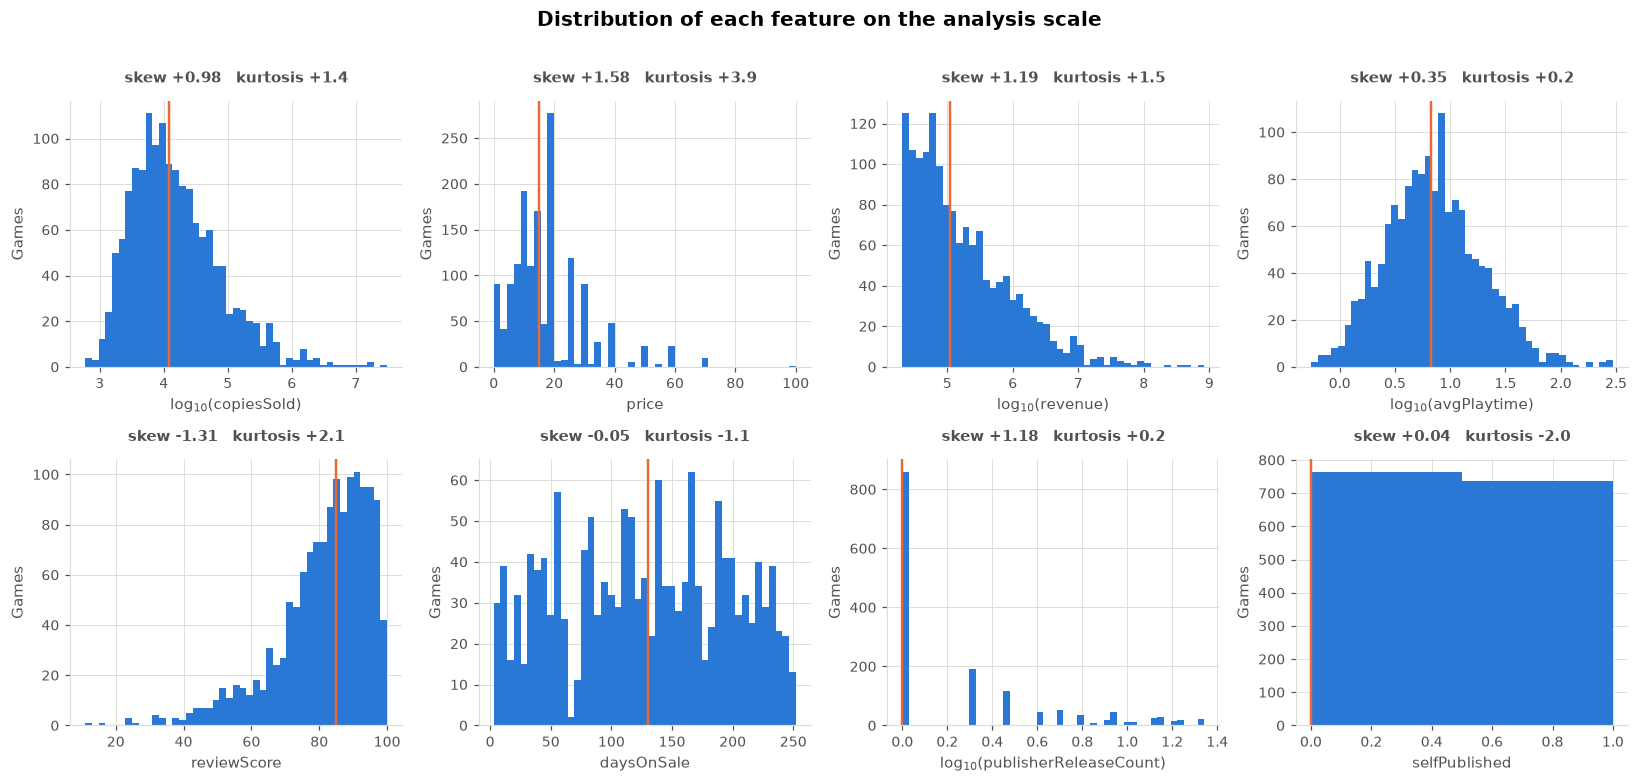

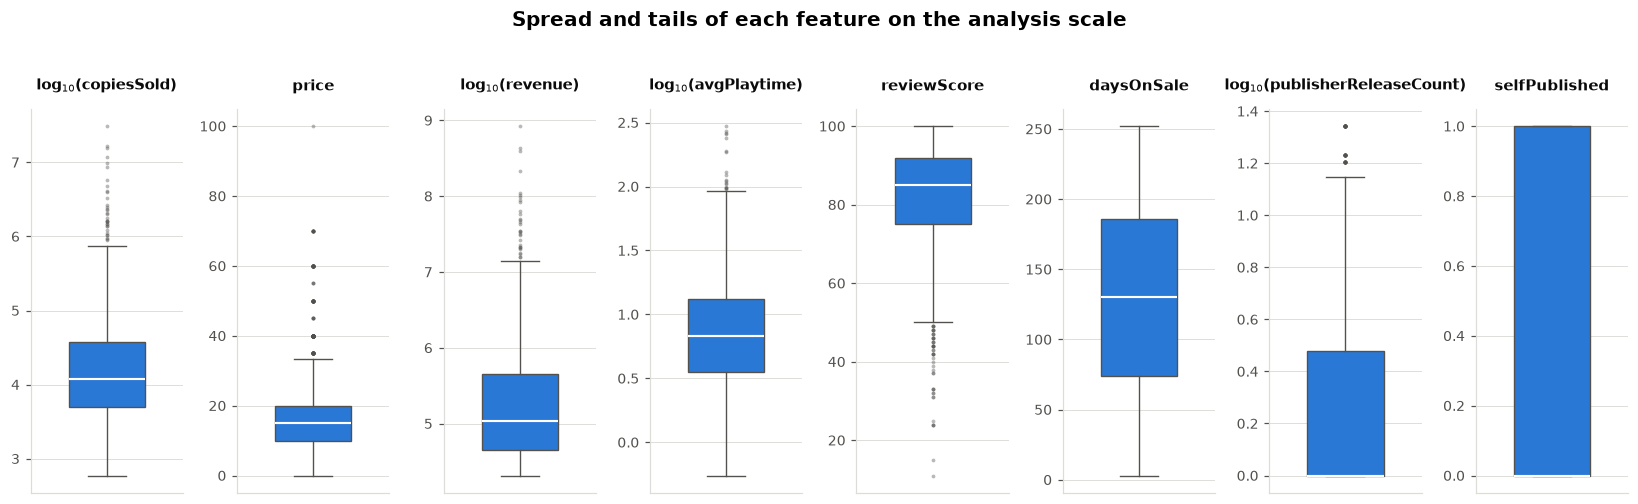

In [10]:
display(plot_distribution_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Distribution of each feature on the analysis scale",
))
display(plot_boxplot_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Spread and tails of each feature on the analysis scale",
))

**Interpretation of the figures.** Plotted on the scale used for the rest of the
analysis, the shapes become legible and several are informative in their own
right.

`log10(copiesSold)` and `log10(avgPlaytime)` are close to symmetric and unimodal
— a single population rather than distinct groups. `log10(revenue)` retains a
visible right tail even after the transform.

**`price` shows a distinctive comb pattern** rather than a smooth distribution:
tall spikes at a few values with near-empty space between them. This is not
noise. It is psychological pricing, and it means `price` is effectively a
discrete variable with a small number of levels rather than a continuous
measurement. Section 2.4 treats it as a measurement artefact.

`daysOnSale` is visibly flat, confirming the near-uniformity the statistics
indicated, and its box plot has **no points outside the whiskers at all**.

`selfPublished` is a two-bar histogram, which is the honest picture of a binary
feature and a reminder that it does not carry the kind of information the
distance-based methods in later chapters are designed to exploit.

### 2.3 The Preprocessing Decision: Should the Heavy Tails Be Transformed?

**Method.** PCA, K-Means, DBSCAN, hierarchical clustering, LOF and the Z-score
method are all built on variances or distances. A feature with a skewness of 22.9
dominates any such quantity: after standardisation, one observation can sit 30
standard deviations from the mean while 99% of the data occupies a fraction of a
single unit.

The alternative is a base-10 logarithm on the four positively skewed features.
Rather than assume it is an improvement, the decision is made by measuring what
it does to the distributions and to the relationships between them.

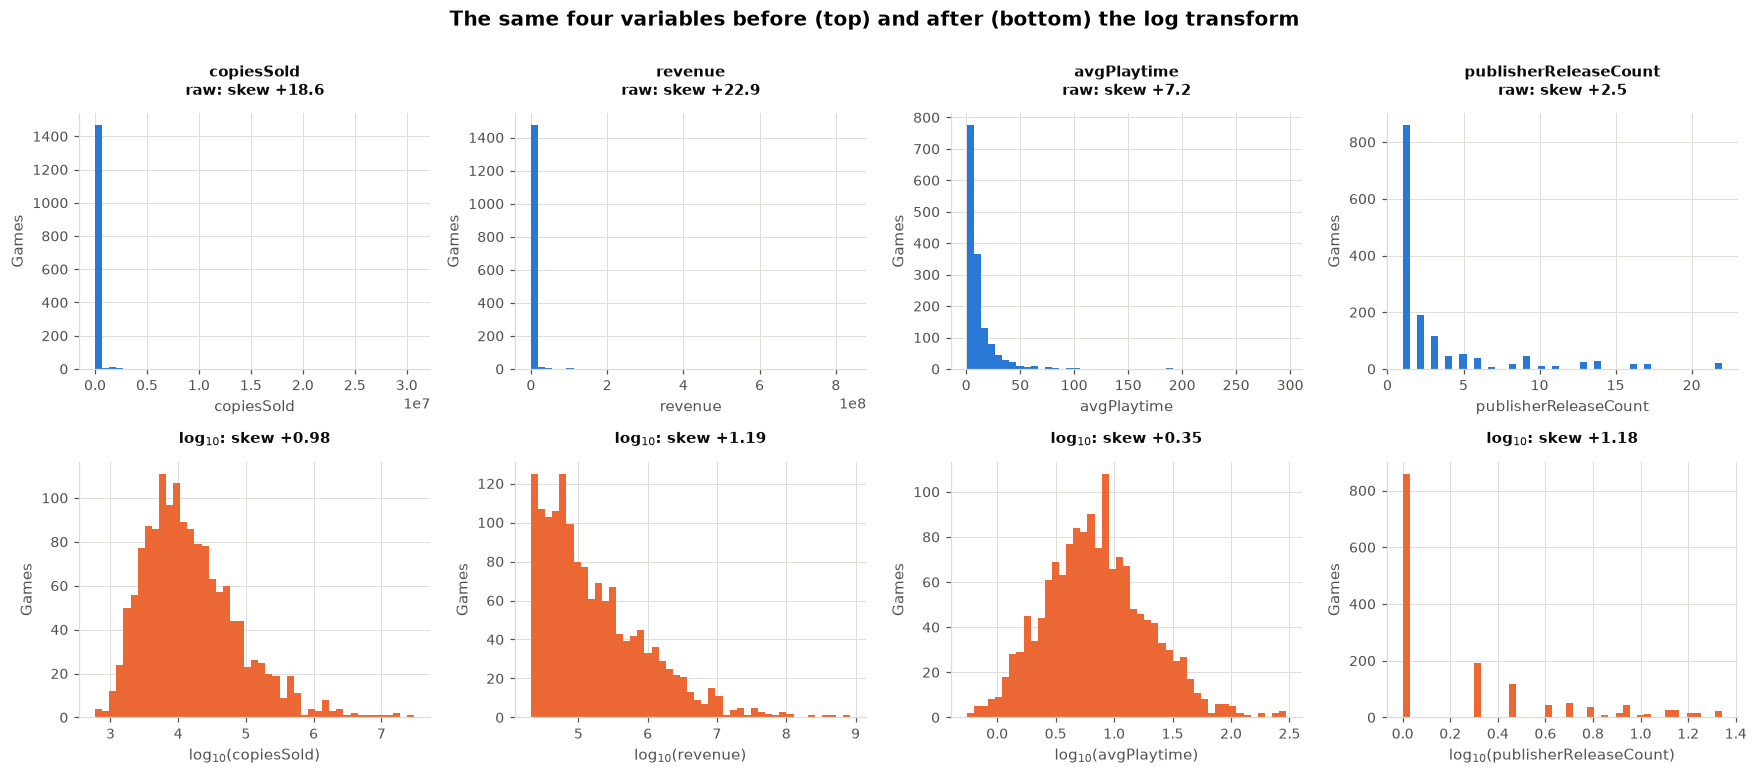

,r (raw),r (log),Change in |r|
Pair,,,
revenue ~ avgPlaytime,0.082,0.453,0.371
copiesSold ~ revenue,0.628,0.897,0.269
copiesSold ~ avgPlaytime,0.099,0.354,0.255
price ~ revenue,0.163,0.398,0.235
price ~ avgPlaytime,0.030,0.255,0.225
publisherReleaseCount ~ selfPublished,-0.426,-0.539,0.113
revenue ~ selfPublished,0.015,-0.120,0.105
price ~ publisherReleaseCount,0.086,0.181,0.095


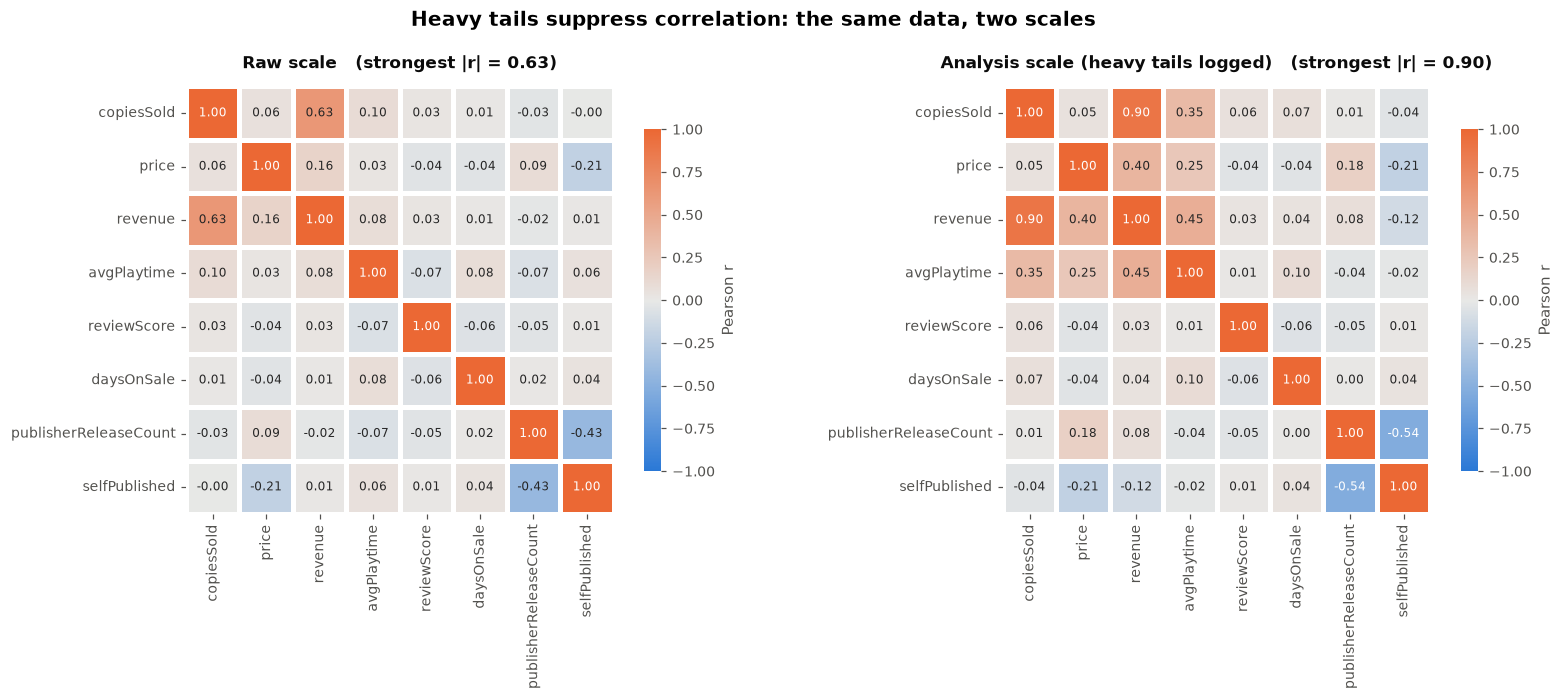

In [11]:
display(plot_transform_effect(raw_matrix, log_matrix, LOG_TRANSFORMED_FEATURES))
display(correlation_shift(raw_matrix, log_matrix).head(8))
display(plot_correlation_pair(raw_matrix, log_matrix))

**Results.** The transform changes both the shapes and the measured
relationships, and the second effect is the more consequential.

| Feature | Skew before → after | Kurtosis before → after |
|---|---|---|
| `revenue` | 22.90 → **1.19** | 607.8 → **1.5** |
| `copiesSold` | 18.60 → **0.98** | 420.0 → **1.4** |
| `avgPlaytime` | 7.16 → **0.35** | 71.5 → **0.2** |
| `publisherReleaseCount` | 2.50 → 1.18 | 6.0 → 0.2 |

**Every pairwise correlation involving a transformed feature becomes stronger,
several of them dramatically:**

| Pair | r (raw) | r (log) | Change |
|---|---|---|---|
| `revenue ~ avgPlaytime` | 0.082 | **0.453** | +0.371 |
| `copiesSold ~ revenue` | 0.628 | **0.897** | +0.269 |
| `copiesSold ~ avgPlaytime` | 0.099 | **0.354** | +0.255 |
| `price ~ revenue` | 0.163 | **0.398** | +0.235 |
| `price ~ avgPlaytime` | 0.030 | **0.255** | +0.225 |

The strongest relationship anywhere in the matrix rises from **0.63 to 0.90**.

**Interpretation.** The raw scale does not merely make the distributions awkward
to plot — **it conceals the structure of the data.** On the raw scale,
`avgPlaytime` and `revenue` correlate at 0.082, a value any analyst would read as
"no relationship". On the log scale the same two variables correlate at 0.453.
Nothing about the data changed; the extreme values were dominating the
covariance, and the relationship among the remaining 99% of games was being
averaged away.

The `copiesSold ~ revenue` pair is the clearest case. Assignment 2 established
that this dataset's vendor computes revenue as approximately copies × price, and
that a regression on the logged variables recovers the identity with coefficients
of 0.988 and 1.005. That relationship is **multiplicative**, so it appears as a
straight line only in log space. On the raw scale it reads as 0.63; on the log
scale, 0.90 — much closer to the near-deterministic link it actually is.

This has a direct consequence for chapter 3. PCA finds directions of maximum
variance in a linear space; if the strongest genuine relationship in the data is
multiplicative, PCA on the raw scale would be looking for the wrong kind of
structure and would spend its first component describing the tail of a single
variable.

**One honest qualification.** The transform is not a universal improvement.
`publisherReleaseCount` is a discrete count with 16 levels and 858 of the 1,500
games sitting at the value 1; taking logarithms reduces its skew from 2.50 to
1.18 but cannot make a spike at a single value into a continuous distribution.
Its histogram remains lumpy, and no transform will change that.

**Conclusion.** The four positively skewed features — `copiesSold`, `revenue`,
`avgPlaytime` and `publisherReleaseCount` — are analysed on a base-10 logarithmic
scale. `price`, `reviewScore`, `daysOnSale` and `selfPublished` are used as they
are: none has a heavy tail, and two are not continuous. Standardisation is
applied on top of this within each method's own pipeline, since PCA and every
distance-based method here would otherwise be dominated by whichever feature
happens to have the largest units.

### 2.4 Outlier Exploration

**Method.** The assignment asks for a discussion of heavy tails, extreme values,
possible noise, measurement artefacts and data-entry problems. These are
different things, and this section keeps them separate: an extreme value is not
necessarily an error, and an error is not necessarily extreme.

Two conventional rules are applied on both scales, not to identify the "real"
outliers but to demonstrate that the count depends on choices the analyst makes.

In [12]:
outlier_counts(raw_matrix, log_matrix)

,"|z| > 3, raw","|z| > 3, analysis scale","1.5xIQR, raw","1.5xIQR, analysis scale"
Feature,,,,
copiesSold,10,17,201,33
price,34,34,140,140
revenue,8,20,223,30
avgPlaytime,24,7,147,17
reviewScore,17,17,48,48
daysOnSale,0,0,0,0
publisherReleaseCount,39,0,199,55
selfPublished,0,0,0,0


**Results.** The number of flagged points depends heavily on both the rule and
the scale.

| Feature | 1.5×IQR raw | 1.5×IQR log | \|z\|>3 raw | \|z\|>3 log |
|---|---|---|---|---|
| `revenue` | 223 | **30** | **8** | **20** |
| `copiesSold` | 201 | 33 | 10 | 17 |
| `avgPlaytime` | 147 | 17 | 24 | 7 |
| `publisherReleaseCount` | 199 | 55 | 39 | **0** |
| `daysOnSale` | 0 | 0 | 0 | 0 |

**Interpretation.** Two findings here are worth more than the counts themselves.

**The IQR rule and the Z-score rule disagree in opposite directions on the same
variable.** For `revenue`, moving to the log scale takes the IQR count *down*
from 223 to 30, while it takes the Z-score count *up* from 8 to 20. The IQR rule
responds to the skew: on the raw scale the quartiles sit close together and the
upper fence falls far below most of the tail, so a seventh of the dataset is
flagged. The Z-score behaves in the opposite way, and the reason is the more
instructive one: **on the raw scale the extreme values inflate the standard
deviation used to judge them.** With a standard deviation of $27.8M, a threshold
of three standard deviations sits at roughly $86M, and only eight games in 1,500
clear it. The outliers hide themselves by making the yardstick enormous. This is
the masking effect, and it is a preview of exactly why chapter 5.1 must treat the
Z-score method's Gaussian assumption sceptically.

**`daysOnSale` has no outliers under any rule on any scale.** Its near-uniform
distribution has nothing that either rule can call extreme. It is a useful
control: it shows that these methods are not flagging points indiscriminately.

**The four categories the assignment asks about, with examples from this
dataset.**

**Heavy tails.** *Black Myth: Wukong* earned $837.8M from 15.5M copies. The next
four largest earn $436M, $392M, $217M and $111M. These are not errors, and they
are not separable from the distribution — they are its tail. Commercial success
in this market is generated multiplicatively, and the resulting distribution has
no natural cut point beyond which a game becomes "too successful to be real".

**Extreme values that are legitimate.** *Firestone: Online Idle RPG* records an
average playtime of **296 hours**, more than 40 times the median of 6.8. Three of
the four highest playtimes belong to free-to-play idle games, a genre designed to
run continuously for months. *The First Descendant* earns **$102M at a listed
price of zero.** Every one of these will be flagged by the methods in chapter 5,
and none is an error. They are a coherent subpopulation — free-to-play
live-service titles — that the feature set describes poorly because `price` says
nothing about how such a game monetises.

**Data-entry problems.** *The Elder Scrolls Online: Gold Road* was recorded with
an average playtime of exactly 0 despite 27,601 owners and $960,791 in revenue.
An MMO expansion cannot have zero average playtime; the value is a placeholder
for a field the source could not populate. The same applies to the 99 games whose
review score was stored as 0: Assignment 1 established that this group **outsells
the scored games**, which a genuine 0% approval rating cannot explain. Both were
converted to missing values in chapter 1. They are the clearest illustration in
this dataset of an error that is not extreme in the ordinary sense — a 0 sits
inside the plausible range of both variables and would pass any range check.

**Measurement artefacts.** `price` takes only **58 distinct values across 1,500
games**, and the six most common cover 54% of the catalogue — $19.99 alone
accounts for 230 games. This is a real property of how games are priced, but for
this analysis it is an artefact: `price` is presented as a continuous variable
and is not one. Distances computed along it are quantised, and any method that
assumes a continuous density will be working against the data. A second and more
serious artefact was established in chapter 1: `revenue` and `copiesSold` are
**model output rather than measurements**, so an extreme value in either may
reflect the estimator's behaviour rather than the game's.

**Possible noise.** With review scores recorded to the nearest percent and
playtimes to fourteen decimal places, the file gives no direct evidence of
measurement noise, and none can be separated from genuine variation without
repeated observations of the same title. What can be said is that the estimation
process is itself a source of uncertainty of unknown size, and chapter 7 returns
to the difficulty of distinguishing that from real variation.

**Conclusion.** The dataset contains a very large number of extreme values, but
few of them are errors. Its two most important variables are heavy-tailed by
nature rather than by contamination, and the log transform adopted in 2.3 makes
them tractable without removing anything. The errors that do exist are
placeholders that sit *inside* the normal range rather than outside it, which is
the harder kind to find. Most importantly for the chapters that follow, the count
of "outliers" in this dataset ranges from 0 to 223 for a single feature depending
on the rule and the scale chosen — **there is no scale-free answer to how many
anomalies this data contains**, which is precisely the ill-posedness the
assignment sets out to examine.

## 3. Dimensionality Reduction (PCA)

**Method — the mathematical intuition.** PCA looks for the directions along which
the data varies most. Given a standardised matrix $X$ with $n$ rows and $p$
features, it computes the covariance matrix $C=\frac{1}{n-1}X^{\top}X$ and takes
its eigendecomposition $C=V\Lambda V^{\top}$. The eigenvectors $v_1,\dots,v_p$
are the principal components — orthogonal directions in feature space — and each
eigenvalue $\lambda_i$ is the variance the data has along its direction. Ordering
by eigenvalue and keeping the leading $k$ gives the $k$-dimensional projection
that preserves more variance than any other, and the share of variance retained
is $\sum_{i\le k}\lambda_i / \sum_i\lambda_i$.

Two properties of that construction matter for reading everything below. PCA is
**linear**: it can only find structure expressible as a rotation of the original
axes. And it is **variance-driven**, so it is a statement about the global spread
of the cloud and says nothing directly about local neighbourhoods or clusters.

**Preprocessing.** The matrix is median-imputed and then standardised. Scaling is
not optional: the eight features are measured in dollars, hours, days, counts and
a binary flag, and PCA maximises variance, so on native units the first component
would simply report which column has the largest numbers. The heavy-tailed
features are on the logarithmic scale decided in section 2.3.

In [13]:
from unsupervised.dimensionality import (
    bootstrap_stability,
    components_needed,
    loading_table,
    neighbourhood_preservation,
    prepare_matrix,
    reconstruction_error,
    timing_table,
    variance_table,
)
from unsupervised.plots import (
    plot_component_stability,
    plot_loadings,
    plot_projection_2d,
    plot_projection_3d,
    plot_reconstruction_error,
    plot_scree,
)
from sklearn.decomposition import PCA

scaled_matrix = prepare_matrix(games, log_transform=True)
scaled_matrix_raw = prepare_matrix(games, log_transform=False)

variance = variance_table(scaled_matrix)
display(variance)
display(components_needed(scaled_matrix))

,Eigenvalue,Explained variance,Cumulative
Component,,,
PC1,2.353,0.2940,0.2940
PC2,1.600,0.1999,0.4938
PC3,1.065,0.1331,0.6269
PC4,0.983,0.1228,0.7497
PC5,0.872,0.1090,0.8586
PC6,0.640,0.0800,0.9386
PC7,0.455,0.0569,0.9955
PC8,0.036,0.0045,1.0000


,Components
Criterion,
80% of variance retained,5
90% of variance retained,6
95% of variance retained,7
Kaiser rule (eigenvalue > 1),3


### 3.1 Explained Variance and How Many Components Are Needed

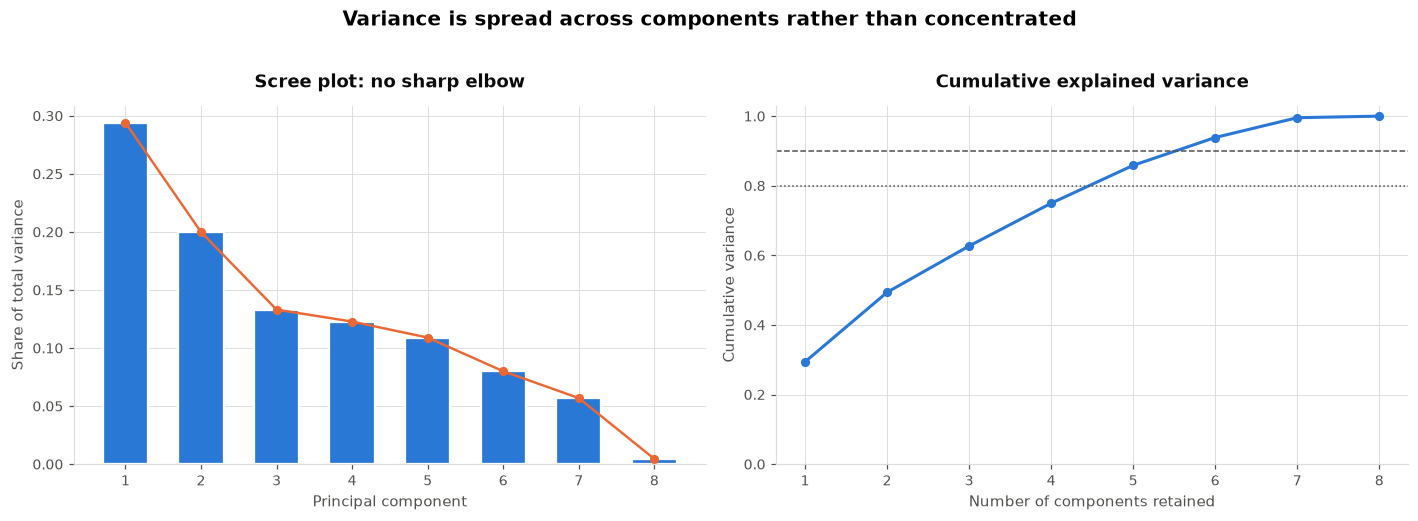

,Analysis scale (logged),Raw scale
Component,,
PC1,0.294,0.211
PC2,0.494,0.402
PC3,0.627,0.544
PC4,0.750,0.666
PC5,0.859,0.779
PC6,0.939,0.886
PC7,0.996,0.955
PC8,1.000,1.000


Components needed for 90% of variance:
  analysis scale : 6
  raw scale      : 7


In [14]:
display(plot_scree(variance))

raw_variance = variance_table(scaled_matrix_raw)
comparison = pd.DataFrame({
    "Analysis scale (logged)": variance["Cumulative"],
    "Raw scale": raw_variance["Cumulative"],
})
display(comparison.round(3))
print("Components needed for 90% of variance:")
print(f"  analysis scale : {int(np.searchsorted(variance['Cumulative'], 0.90) + 1)}")
print(f"  raw scale      : {int(np.searchsorted(raw_variance['Cumulative'], 0.90) + 1)}")

**Results.** The variance is spread across the components rather than
concentrated in a few.

| | PC1 | PC2 | PC3 | PC4 | PC5 | PC6 | PC7 | PC8 |
|---|---|---|---|---|---|---|---|---|
| Explained | 29.4% | 20.0% | 13.3% | 12.3% | 10.9% | 8.0% | 5.7% | 0.5% |
| Cumulative | 29.4% | 49.4% | 62.7% | 75.0% | 85.9% | 93.9% | 99.6% | 100% |

| Criterion | Components |
|---|---|
| 80% of variance | 5 |
| 90% of variance | **6** |
| 95% of variance | 7 |
| Kaiser rule (eigenvalue > 1) | 3 |

**Interpretation — how many components are needed?** The answer depends on the
criterion, and the criteria disagree by a factor of two.

The **Kaiser rule** retains 3 components, keeping every direction that explains
more variance than a single standardised feature would. The **variance-threshold
rule** at the conventional 90% retains **6 of 8**, and even 80% requires 5. The
**scree plot shows no elbow**: the sequence 29.4, 20.0, 13.3, 12.3, 10.9, 8.0 has
no point at which it drops sharply, so the visual criterion gives no clear answer
at all.

**This disagreement is itself the finding.** A dataset with strong redundancy
produces a steep scree curve and all three criteria agree. Here they do not,
because the underlying structure is genuinely spread out: **discarding two of
eight dimensions costs 6% of the variance, and there is no natural point at which
to stop.**

The comparison with the untransformed matrix confirms the section 2.3 decision.
On the raw scale PC1 captures only 21.1% and reaching 90% requires **7**
components; on the analysis scale PC1 captures 29.4% and 90% requires 6. The log
transform makes the data measurably more compressible, because it converts the
multiplicative relationship between revenue and copies into a linear one that
PCA is able to represent.

### 3.2 Component Interpretation and Correlation Structure

,PC1,PC2,PC3,PC4
copiesSold,0.539,-0.238,0.077,0.229
price,0.322,0.254,-0.023,-0.535
revenue,0.617,-0.123,0.058,0.006
avgPlaytime,0.411,-0.170,-0.128,-0.169
reviewScore,0.029,-0.104,0.703,0.475
daysOnSale,0.060,-0.110,-0.689,0.560
publisherReleaseCount,0.139,0.643,-0.037,0.239
selfPublished,-0.178,-0.631,-0.049,-0.191


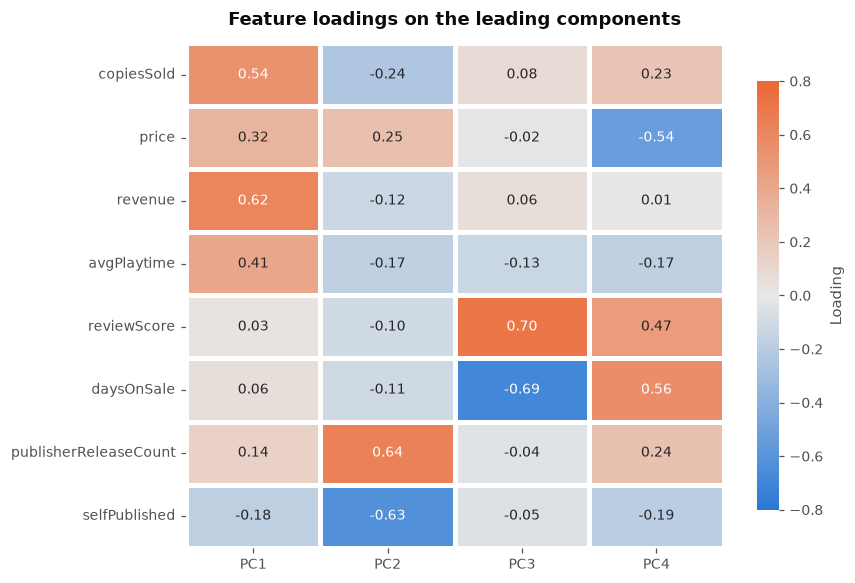

In [15]:
loadings = loading_table(scaled_matrix, n_components=4)
display(loadings)
display(plot_loadings(loadings))

**Results and interpretation — what the components mean.** Three of the four
leading components have a clean reading.

**PC1 (29.4%) is a commercial-scale axis.** Its largest loadings are `revenue`
(0.617), `copiesSold` (0.539), `avgPlaytime` (0.411) and `price` (0.322), all
positive. A game scores high on PC1 by selling more copies, earning more, costing
more and being played longer. Notably `reviewScore` loads 0.029 — essentially
zero — so **critical reception contributes nothing to the dataset's dominant
axis of variation.** That is consistent with Assignment 1, which found review
score uncorrelated with commercial outcome.

**PC2 (20.0%) is a publishing-structure axis.** It contrasts
`publisherReleaseCount` (+0.643) against `selfPublished` (−0.631), with `price`
(+0.254) alongside. High PC2 means a title from a prolific external publisher;
low PC2 means a self-published one. This is close to a pure two-variable
contrast, which is what the correlation of −0.54 between those features implies.

**PC3 (13.3%) pairs reception against recency**, loading `reviewScore` (+0.703)
against `daysOnSale` (−0.689). These are the two features that correlate with
almost nothing else, so PCA places them together in a component of their own —
not because they are related, but because whatever variance remains after PC1 and
PC2 belongs largely to them.

**Which variables are strongly correlated, and how does that affect the result?**
Section 2.3 established the correlation structure: `copiesSold ~ revenue` at
**0.90** is by far the strongest pair, followed by `revenue ~ avgPlaytime` (0.45),
`price ~ revenue` (0.40) and `publisherReleaseCount ~ selfPublished` (−0.54).

The effect on PCA is direct and visible in the loadings. The four mutually
correlated commercial variables collapse into PC1, and the two publishing
variables collapse into PC2. **PCA has not discovered anything the correlation
matrix did not already contain** — it has reorganised it, replacing eight
correlated axes with a smaller number of uncorrelated ones. That is precisely
what the method does, and it is worth stating plainly rather than presenting the
components as a discovery.

The absence of *more* correlation is what limits the compression. With only one
pair above 0.5 in absolute value, most of the eight features carry variance that
no other feature shares, and a method that works by exploiting shared variance
has little to exploit.

### 3.3 Projections into Two and Three Dimensions

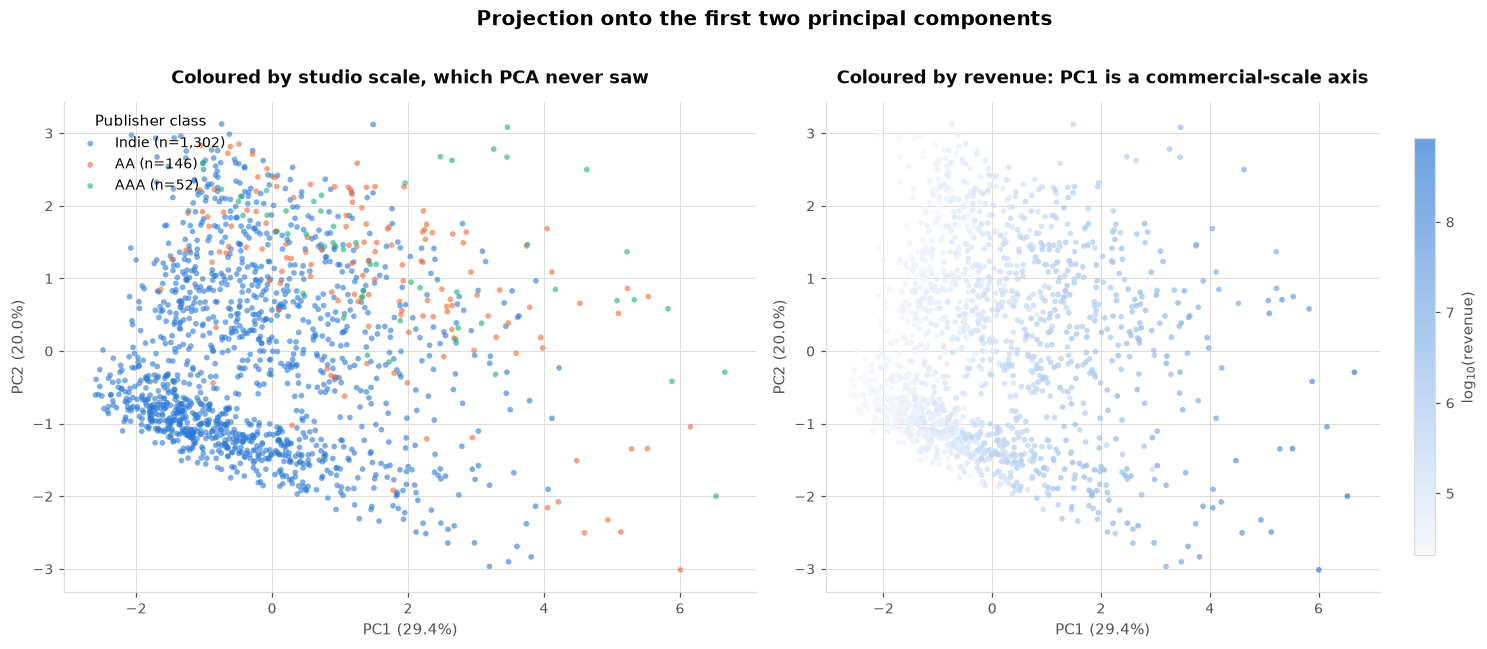

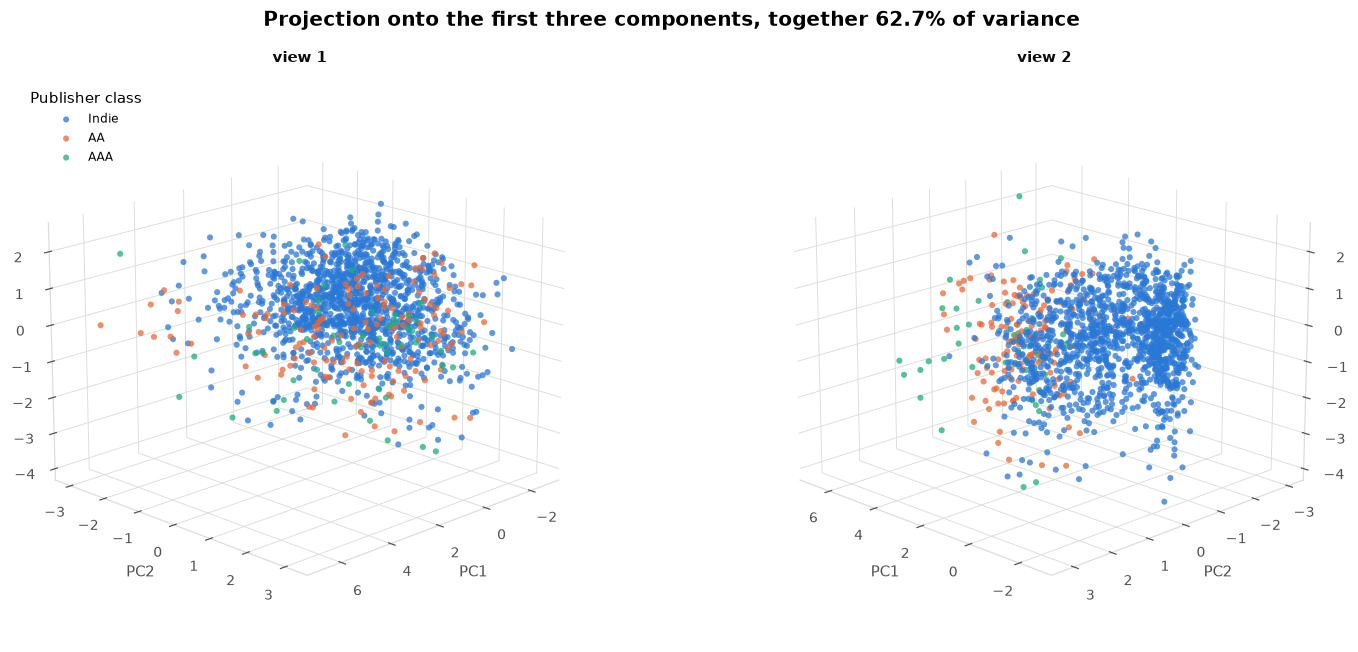

In [16]:
scores = PCA(n_components=3, random_state=42).fit_transform(scaled_matrix)
display(plot_projection_2d(scores, games, variance))
display(plot_projection_3d(scores, games, variance))

**Results and interpretation.** Both projections show **a single diffuse cloud
with no separated groups.** There are no gaps, no distinct lobes and no visible
boundaries — in two dimensions or in three, from either viewing angle.

The annotation confirms that this is not a failure of the projection to represent
something real. Colouring by `plotClass`, a variable PCA never saw, shows AA and
AAA titles drifting towards higher PC1 exactly as the loadings predict, but
**overlapping the Indie population almost completely.** Studio scale shifts a
game's position along PC1; it does not place it in a separate region. Colouring
by revenue shows the same gradient continuously, with no threshold at which the
cloud divides.

**This is a substantive result for chapter 4 and it is reported as such.** The
assignment states explicitly that meaningful clusters may not exist. The leading
two components carry 49.4% of the variance, and within them the data looks like
one population with continuous internal variation rather than several
populations. Any clustering algorithm applied in chapter 4 will still return
clusters, because they are constructed to; the question that chapter has to
answer is whether those partitions correspond to anything, and this projection is
the first evidence that they may not.

**A caution about reading it.** These pictures show 49.4% and 62.7% of the total
variance. The remaining 37–51% lies in directions not displayed, and structure
living there would be invisible here. Section 3.4 measures how much distortion
that involves, and section 7 returns to why post-projection visualisations can
mislead.

### 3.4 How Much Information Is Lost, and What Kind

,Variance kept,copiesSold,price,revenue,avgPlaytime,reviewScore,daysOnSale,publisherReleaseCount,selfPublished
Components,,,,,,,,,
2,49.4%,0.48,0.81,0.28,0.75,0.99,0.99,0.54,0.54
3,62.7%,0.47,0.81,0.28,0.73,0.67,0.68,0.54,0.54
4,75.0%,0.41,0.61,0.28,0.71,0.48,0.40,0.48,0.50
5,85.9%,0.16,0.38,0.23,0.63,0.05,0.17,0.48,0.50
6,93.9%,0.12,0.05,0.14,0.06,0.02,0.05,0.48,0.47


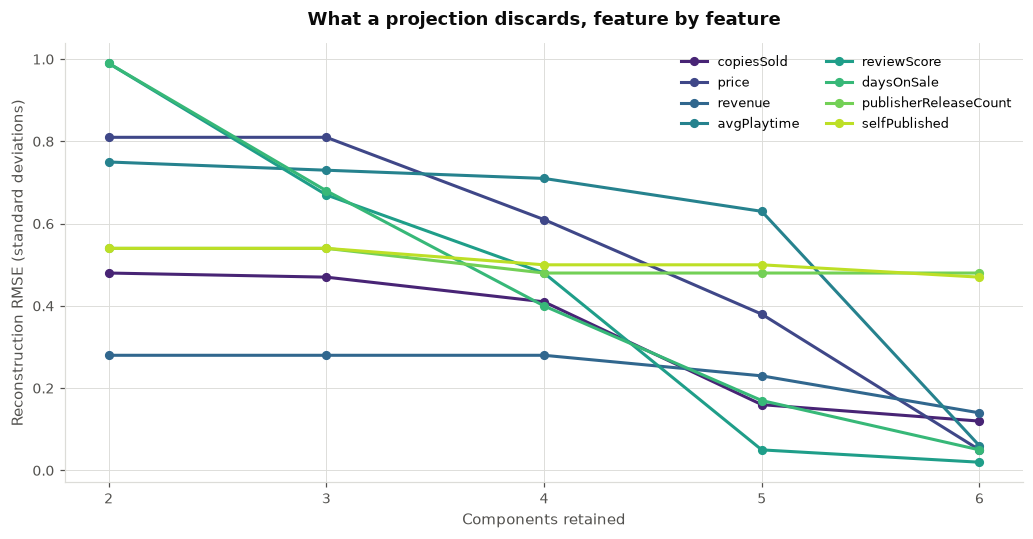

,Trustworthiness (k=15)
Projection,
2D,0.848
3D,0.920
5D,0.983


In [17]:
display(reconstruction_error(scaled_matrix))
display(plot_reconstruction_error(reconstruction_error(scaled_matrix)))
display(neighbourhood_preservation(scaled_matrix))

**Results.** Reporting a single "information lost" percentage would obscure the
more useful fact, which is *which* information is lost. Rebuilding the data from
$k$ components and measuring the per-feature error, in standard deviations,
gives:

| Components | Variance kept | `revenue` | `copiesSold` | `price` | `reviewScore` | `selfPublished` |
|---|---|---|---|---|---|---|
| 2 | 49.4% | **0.28** | 0.48 | 0.81 | 0.99 | 0.54 |
| 3 | 62.7% | 0.28 | 0.47 | 0.81 | 0.67 | 0.54 |
| 5 | 85.9% | 0.23 | 0.16 | 0.38 | 0.05 | 0.50 |
| 6 | 93.9% | 0.14 | 0.12 | 0.05 | 0.02 | **0.47** |

Neighbourhood preservation, measured by trustworthiness at $k=15$:

| Projection | Trustworthiness |
|---|---|
| 2D | **0.848** |
| 3D | 0.920 |
| 5D | 0.983 |

**Interpretation — the loss is uneven, and that matters more than its size.**
A two-component projection reconstructs `revenue` to within 0.28 standard
deviations but leaves `reviewScore` at 0.99 — essentially the whole of its
variance is discarded. In other words, **the 2D picture in section 3.3 contains
almost no information about how well a game was reviewed.** A reader inspecting
that scatter for patterns in reception would find none, and would be right to
find none, but for the wrong reason.

`selfPublished` and `publisherReleaseCount` behave differently again: their error
stays near 0.48 even at six components and 93.9% variance retained. Their shared
variance is captured by PC2, but each also carries independent variance that
survives into the discarded components. A binary feature is intrinsically hard
for a linear projection to represent.

**Local versus global structure.** Explained variance is a global measure — it
says how much of the total spread is preserved, and nothing about whether points
near each other stay near each other. Trustworthiness answers the local question,
and the answer is that **the 2D projection preserves about 85% of local
neighbourhood structure**: roughly one neighbour in seven appearing close in the
picture was not actually close in the eight-dimensional space. Three dimensions
recovers this to 0.92 and five to 0.98.

This gap between global and local fidelity is exactly the mechanism by which a
PCA plot can mislead. Two points can appear adjacent in the projection while
being separated along the discarded directions, and a density-based method such
as DBSCAN or LOF — which depends entirely on local neighbourhoods — would reach
different conclusions in the projected space than in the original one. Every such
method in chapters 4 and 5 is therefore run on the **full eight-dimensional
matrix**, with PCA used only to display the results.

### 3.5 Stability and Computational Cost

,Mean |cosine|,5th percentile,Resamples below 0.9
Component,,,
PC1,0.996,0.991,0
PC2,0.993,0.983,0
PC3,0.891,0.500,54


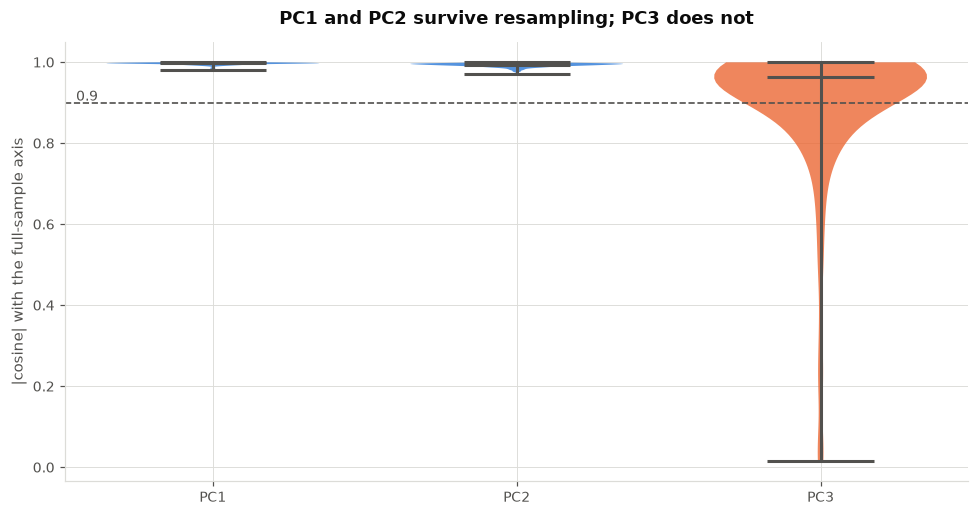

,Seconds for 20 fits
Components,
2,0.0030
3,0.0025
8,0.0023


In [18]:
stability, similarity_samples = bootstrap_stability(scaled_matrix, n_components=3, n_resamples=200)
display(stability)
display(plot_component_stability(similarity_samples))
display(timing_table(scaled_matrix))

**Results.** Refitting PCA on 200 bootstrap resamples and comparing each axis
with the full-sample axis by absolute cosine similarity:

| Component | Mean \|cosine\| | 5th percentile | Resamples below 0.9 |
|---|---|---|---|
| PC1 | 0.996 | 0.991 | 0 |
| PC2 | 0.993 | 0.983 | 0 |
| **PC3** | **0.891** | **0.500** | **54 of 200** |

**Interpretation.** PC1 and PC2 are highly stable: no resample moved either axis
appreciably, so the commercial-scale and publishing-structure interpretations in
3.2 are properties of the data rather than of this particular sample.

**PC3 is not stable.** In 54 of 200 resamples it rotated far enough that its
cosine with the full-sample axis fell below 0.9, and at the 5th percentile it
reached 0.500 — a rotation of about 60 degrees. The cause is visible in the
eigenvalues: PC3 explains 13.3% and PC4 explains 12.3%, a difference of one
percentage point. When two eigenvalues are close, the *plane* they span is well
determined but the individual axes within that plane are nearly free to rotate,
and resampling is enough to spin them.

The consequence is a limit on interpretation. The "reception versus recency"
reading of PC3 in section 3.2 describes this sample; a different sample of 1,500
games would likely produce a differently-oriented third axis spanning the same
subspace. **PC1 and PC2 may be interpreted; PC3 should not be, beyond noting
which variables occupy that subspace.**

**Computational cost.** Twenty full fits take under 0.01 seconds regardless of
the number of components requested. At $n=1{,}500$ and $p=8$ the eigendecomposition
is trivial, and cost plays no part in the choice of method here. This would not
remain true at large $p$: exact PCA costs $O(np^2 + p^3)$, so it is the number of
*features*, not rows, that eventually becomes limiting — which is worth noting
because the anomaly-detection methods in chapter 5 scale quite differently.

### 3.6 Does the Reduced Representation Improve on the Original?

**Interpretation.** Taking the assignment's question directly: **for this dataset,
only marginally, and the honest answer is that PCA offers limited compression
here.**

The evidence is consistent across the chapter. Retaining 90% of the variance
requires 6 of 8 components — a reduction of 25% in dimensionality. The scree plot
has no elbow. Reconstruction error at two components leaves several features
essentially unrepresented. The correlation matrix contains exactly one pair above
0.5 in absolute value.

**The level of redundancy in the original data is low.** This is not a defect of
the analysis; it is a property of the feature set, and it was partly designed in.
Chapter 1 deliberately excluded the candidate features that were algebraic
functions of others — `revenuePerCopy`, `revenuePerDay`, `priceRealisation`, and
`releaseMonth` at −0.99 with `daysOnSale`. Had those been retained, PCA would have
produced an impressive-looking scree plot and a high first-component share, and
**all of it would have been an artefact of the feature set rather than a finding
about games.** The modest compression reported here is the price of not having
manufactured redundancy, and it is the more honest result.

**Where PCA is nonetheless useful in this analysis.** Not as a compression step,
but as an instrument. It provides a coordinate system for displaying the results
of chapters 4 and 5; it supplies, through the loadings, a compact summary of the
correlation structure; and section 3.4's trustworthiness measurement quantifies
how much a two-dimensional picture can be trusted — which is needed to interpret
every projection that follows.

**Interpretability.** The components are interpretable to the extent that their
loadings are concentrated, and here PC1 and PC2 are. But every component is a
weighted mixture of all eight features, so a position on PC1 has no unit and
cannot be quoted to a non-technical audience without translation. The original
features are individually meaningful — dollars, hours, a count — and the
components are not. That trade is worth making for visualisation and not worth
making for the analysis itself.

**Conclusion.** The dataset's variance is spread rather than concentrated: 6 of 8
components are needed for 90%, the scree plot has no elbow, and the three
conventional criteria disagree between 3 and 7 components. PC1 is a
commercial-scale axis and PC2 a publishing-structure axis, both stable under
resampling; PC3 is not stable and should not be interpreted. The projections show
one diffuse cloud with no separated groups, which is the first evidence that this
dataset may not contain distinct clusters. Because the 2D projection preserves
only 85% of local neighbourhood structure, every distance-based method in the
following chapters operates on the full eight-dimensional matrix, and PCA is used
for display only.

## 4. Clustering Analysis

**Method.** Three methods are applied to the samples — K-Means, DBSCAN and Ward
hierarchical clustering — and a fourth analysis clusters the feature space by
operating on the transpose of the data matrix. All four run on the full
eight-dimensional standardised matrix, for the reason established in section
3.4: the 2D projection preserves only 85% of local neighbourhood structure, and
density-based methods depend entirely on local neighbourhoods.

Every parameter is swept rather than assumed. This matters more than usual here.
Section 3.3 found one diffuse cloud with no visible separation, so there is a
real risk of choosing the parameters that produce the most attractive partition
and then reporting it as a discovery. **Clustering algorithms always return
clusters — they are constructed to.** The question this chapter must answer is
whether those partitions correspond to anything in the data.

,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Smallest cluster
k,,,,,
2,9659.0,0.214,363.0,1.855,470
3,8174.0,0.196,350.3,1.722,313
4,7567.0,0.171,292.1,1.827,261
5,7030.0,0.171,264.2,1.699,146
6,6543.0,0.170,249.2,1.694,129
7,6142.0,0.161,237.4,1.708,120
8,5806.0,0.168,227.4,1.649,78
9,5525.0,0.165,218.4,1.578,73
10,5300.0,0.162,209.3,1.575,66


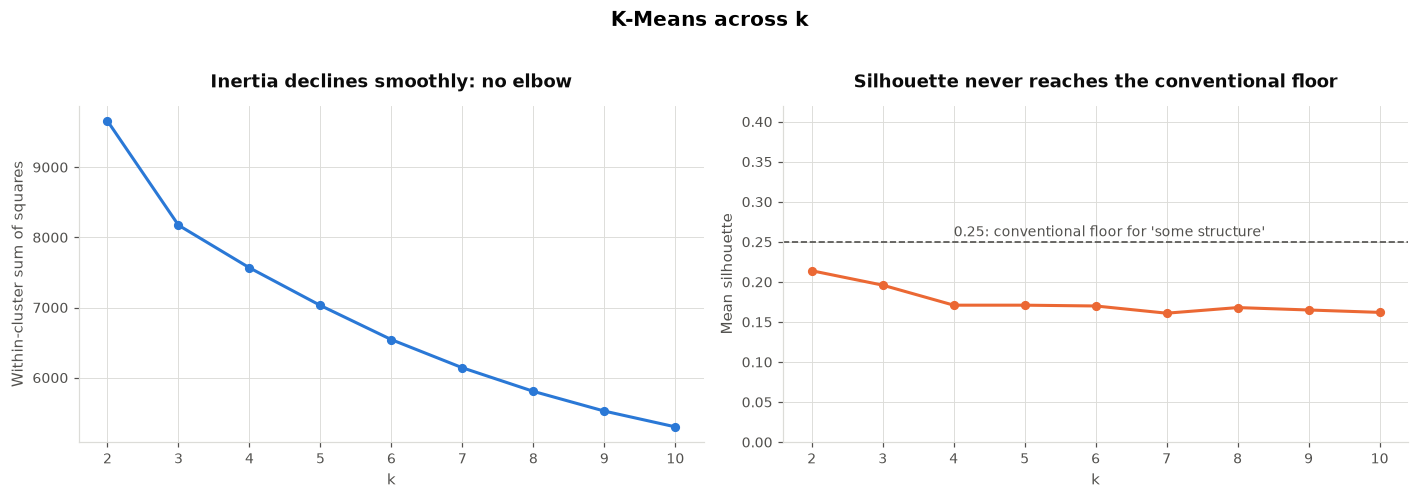

In [19]:
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import KMeans

from unsupervised.clustering import (
    DBSCAN_EPS,
    DBSCAN_MIN_SAMPLES,
    HIERARCHICAL_K,
    KMEANS_K,
    agreement_matrix,
    cluster_features,
    compare_linkages,
    evaluate_partitions,
    feature_distance_matrix,
    feature_isolation,
    fit_all,
    k_distance_curve,
    profile_clusters,
    sweep_dbscan,
    sweep_kmeans,
    variance_ratio,
)
from unsupervised.plots import (
    plot_clusters_on_pca,
    plot_dendrogram,
    plot_feature_space,
    plot_k_distance,
    plot_kmeans_sweep,
    plot_metric_disagreement,
)

kmeans_sweep = sweep_kmeans(scaled_matrix)
display(kmeans_sweep)
display(plot_kmeans_sweep(kmeans_sweep))

### 4.1 K-Means

**Mathematical intuition.** K-Means partitions the points into $k$ groups by
minimising the within-cluster sum of squared distances to the cluster centres:

$$\arg\min_{S}\sum_{i=1}^{k}\sum_{x\in S_i}\lVert x-\mu_i\rVert^2$$

where $\mu_i$ is the mean of cluster $S_i$. Lloyd's algorithm alternates between
assigning each point to its nearest centre and recomputing the centres, which
decreases the objective at every step and converges to a local minimum.

**Assumptions.** That clusters are roughly spherical and of comparable spread,
since the objective is isotropic squared Euclidean distance; that they are of
broadly similar size, because the mean is pulled towards dense regions; and that
$k$ is known. It also assumes every point belongs to a cluster — there is no
provision for noise.

**Strengths.** Fast, deterministic given a seed, and its output is easy to
describe: each cluster has a centre that can be read as a profile.
**Weaknesses.** It cannot represent elongated or nested shapes, it is sensitive
to initialisation, and — most importantly here — **it will partition data that
has no natural partition**, because the objective always decreases as $k$ grows.

**Results.** Silhouette peaks at $k=2$ with **0.214** and declines thereafter;
$k=3$ gives 0.196. Inertia falls smoothly from 9,659 to 5,300 across $k=2$ to
$k=10$ with **no elbow** at any point. Calinski-Harabasz is highest at $k=2$
(363.0) and declines monotonically. Davies-Bouldin never falls below 1.575.

**Interpretation.** A silhouette of 0.21 is weak. The conventional reading is
that values below roughly 0.25 indicate no substantial structure, and every value
across the entire sweep sits below that line. The smooth inertia curve says the
same thing differently: an elbow appears when adding a cluster stops paying,
which happens when the data contains a fixed number of real groups. Here each
additional cluster pays about as much as the last, which is what happens when an
algorithm is slicing a continuum.

$k=3$ is carried forward — not because the evidence favours it, but because it
gives a partition to compare against the other two methods. Section 4.4 returns
to whether any of these partitions is meaningful.

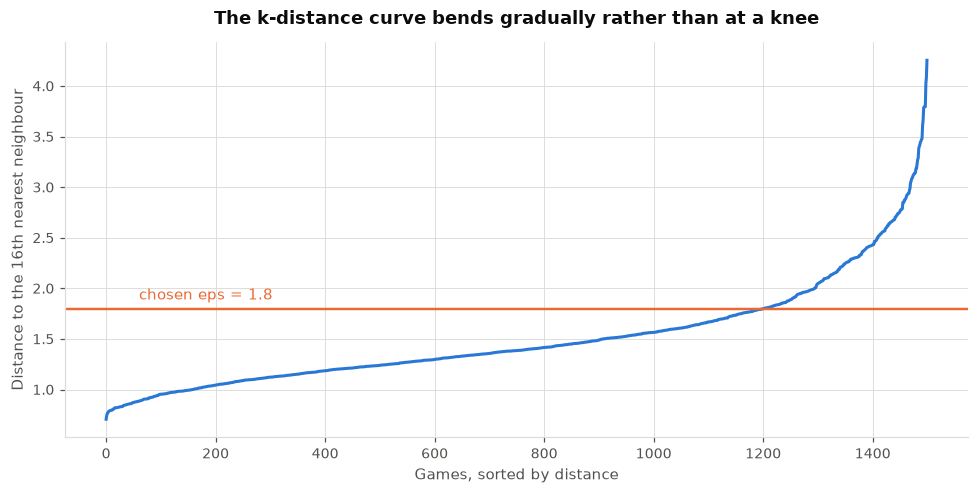

,eps,min_samples,Clusters,Noise %,Largest cluster %,Silhouette (excl. noise)
0,1.5,8,2,11.5%,44.6%,0.216
1,1.5,16,2,16.9%,42.7%,0.227
2,1.5,24,2,21.0%,41.3%,0.233
3,1.8,8,2,5.7%,47.5%,0.202
4,1.8,16,2,7.7%,46.3%,0.207
5,1.8,24,2,9.3%,45.5%,0.212
6,2.0,8,2,3.4%,48.9%,0.196
7,2.0,16,2,4.5%,48.2%,0.199
8,2.0,24,2,5.8%,47.6%,0.203
9,2.2,8,1,1.6%,98.4%,NaN


In [20]:
display(plot_k_distance(k_distance_curve(scaled_matrix), DBSCAN_EPS, DBSCAN_MIN_SAMPLES))
display(sweep_dbscan(scaled_matrix))

### 4.2 DBSCAN

**Mathematical intuition.** DBSCAN defines clusters as regions of high density
rather than as groups around centres. A point is a *core point* if at least
`min_samples` points lie within distance `eps` of it. Core points that are within
`eps` of each other are joined into the same cluster, non-core points within
reach of a core point are attached as border points, and everything else is
labelled **noise**. No number of clusters is specified in advance; it emerges
from the density structure.

**Assumptions.** That clusters are dense regions separated by sparser ones, and
that a single density threshold applies everywhere. It makes no assumption about
shape, which is its main advantage over K-Means.

**Strengths.** Finds arbitrarily shaped clusters, discovers the number of
clusters itself, and explicitly models noise — which is why it is often used for
anomaly detection. **Weaknesses.** It is very sensitive to `eps`, it cannot
handle clusters of differing density with one threshold, and in higher dimensions
distances concentrate so that a single `eps` separating dense from sparse becomes
harder to find.

**Choosing `eps`.** The conventional heuristic reads it off the knee of the
sorted k-distance curve. Here **the curve bends gradually rather than at a knee**
— the 50th, 75th, 90th and 95th percentiles of the 16th-neighbour distance are
1.38, 1.70, 2.24 and 2.59 — so no value is clearly indicated, which is itself
consistent with the absence of a density gap. A value of 1.8 was chosen from the
sweep as the setting that produces more than one cluster without labelling an
implausible share of the data as noise.

**Results.** The sweep divides sharply at `eps ≈ 2.1`. Below it DBSCAN returns
exactly **2** clusters. Above it the entire dataset collapses into **1 cluster
containing 96–99% of the points**. No parameter combination produced three or
more clusters.

**Interpretation — and an unexpected finding examined below.** The collapse at
`eps ≥ 2.2` is the important result: at that radius every point is
density-reachable from every other, meaning **the data forms one connected
region with no density gap running through it.** That is direct evidence against
the existence of separated clusters, obtained from a method that would have found
them had they been there.

In [21]:
dbscan_labels = fit_all(scaled_matrix)[f"DBSCAN (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})"]
kmeans_two = KMeans(n_clusters=2, n_init=20, random_state=42).fit_predict(scaled_matrix)

check = pd.DataFrame({
    "Games": pd.Series(dbscan_labels).value_counts().sort_index(),
    "selfPublished share": games.assign(c=dbscan_labels).groupby("c")["selfPublished"].mean().round(3),
    "Median revenue": games.assign(c=dbscan_labels).groupby("c")["revenue"].median().round(0),
})
check.index = ["noise" if i == -1 else f"cluster {i}" for i in check.index]
display(check)

from sklearn.metrics import adjusted_rand_score
print(f"ARI between the DBSCAN partition and K-Means at k=2: "
      f"{adjusted_rand_score(dbscan_labels, kmeans_two):.3f}")

,Games,selfPublished share,Median revenue
noise,115,0.4,1902618.0
cluster 0,690,1.0,73644.0
cluster 1,695,0.0,125882.0


ARI between the DBSCAN partition and K-Means at k=2: 0.087


**What DBSCAN actually found.** The two clusters are **a perfect split on
`selfPublished`**: cluster 0 is 100% self-published and cluster 1 is 0%. DBSCAN
did not find two populations of games — it found the two parallel slabs that a
standardised binary feature creates in Euclidean space. With seven continuous
features and one binary, the point cloud sits in two copies of the same shape
offset along a single axis, and the gap between them is wide enough at
`eps ≤ 2.0` to prevent density connection.

The agreement with K-Means at $k=2$ is **ARI 0.087** — essentially chance. The
two methods, given the same data and the same number of clusters, found
completely different things: K-Means cut along the commercial-scale axis while
DBSCAN cut along the binary flag.

This is the concrete form of the caution recorded in chapter 1.3. `selfPublished`
is a legitimate feature, but it carries full weight in Euclidean distance after
standardisation, and here it dominates a density-based method entirely. **This is
a property of the feature-space representation, not of any tuning parameter**,
and it would not have been visible from the parameter sweeps alone.

,Cophenetic r,Silhouette at k=3,Cluster sizes
Linkage,,,
ward,0.487,0.158,"[420, 561, 519]"
complete,0.524,0.141,"[36, 405, 1059]"
average,0.679,0.263,"[4, 104, 1392]"
single,0.526,0.337,"[1498, 1, 1]"


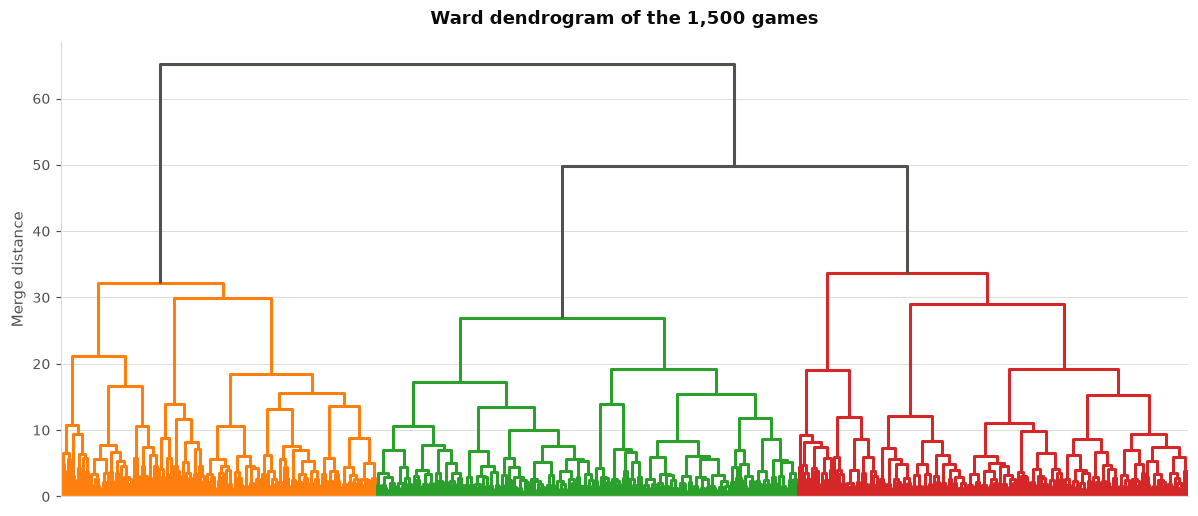

In [22]:
display(compare_linkages(scaled_matrix, k=HIERARCHICAL_K))
display(plot_dendrogram(linkage(scaled_matrix, method="ward"),
                        title="Ward dendrogram of the 1,500 games",
                        colour_threshold=40))

### 4.3 Hierarchical Clustering

**Mathematical intuition.** Agglomerative clustering begins with every point in
its own cluster and repeatedly merges the two closest clusters, producing a tree.
The linkage rule defines "closest": *single* uses the minimum distance between
members, *complete* the maximum, *average* the mean, and *Ward* merges the pair
that produces the smallest increase in total within-cluster variance,

$$\Delta = \frac{n_i n_j}{n_i+n_j}\lVert \mu_i-\mu_j\rVert^2 .$$

Cutting the tree at a chosen height yields a partition.

**Assumptions.** No assumption about shape or the number of clusters, but the
linkage rule imposes one implicitly: Ward assumes compact, variance-minimising
groups and behaves much like K-Means, while single linkage assumes only
connectivity and can produce long chains.

**Strengths.** The dendrogram shows structure at every scale at once, and no $k$
need be fixed in advance. **Weaknesses.** Merges are greedy and irreversible, the
cost is $O(n^2)$ in memory, and different linkages can give entirely different
answers on the same data — as they do here.

**Results.** The four linkage rules disagree substantially:

| Linkage | Cophenetic r | Silhouette at k=3 | Cluster sizes |
|---|---|---|---|
| Ward | 0.487 | 0.158 | 420, 561, 519 |
| Complete | 0.524 | 0.141 | 36, 405, 1059 |
| Average | 0.679 | 0.263 | 4, 104, 1392 |
| **Single** | 0.526 | **0.337** | **1498, 1, 1** |

**Interpretation.** The cophenetic correlation measures how faithfully the tree's
implied distances reproduce the real pairwise distances. The best value here is
**0.679** and Ward's is **0.487** — all low. **The dendrogram is imposing a
hierarchy that the data does not have.**

The single-linkage row is worth dwelling on because it is a trap. It achieves the
**highest silhouette of any method in this chapter, 0.337** — and it does so by
placing 1,498 games in one cluster and isolating two singletons. A singleton has
a perfect silhouette by construction, and with 1,498 points in one group the mean
is dominated by whatever that group scores. **A metric can be optimised by a
partition that is analytically worthless**, which is the practical reason
section 4.4 does not rely on any single number.

Ward at $k=3$ is carried forward: it is the only rule producing balanced clusters,
and balance is the minimum condition for a partition to be worth interpreting.

### 4.4 Evaluation: Is the Named Metric Suitable?

**Method.** The assignment specifies a particular metric — the average variance
within each cluster compared with the global variance — and asks whether it is
suitable, requesting an alternative if not. It is computed below for every
partition, alongside three standard alternatives and two deliberate controls: a
random labelling, and K-Means at a deliberately excessive $k$.

,Clusters,Variance ratio,Silhouette,Calinski-Harabasz,Davies-Bouldin
Partition,,,,,
K-Means (k=3),3,0.731,0.196,350.3,1.722
"DBSCAN (eps=1.8, min_samples=16)",2,0.798,0.207,349.5,1.896
Ward hierarchical (k=3),3,0.745,0.158,291.7,1.912


,Clusters,Variance ratio,Silhouette,Calinski-Harabasz,Davies-Bouldin
Partition,,,,,
K-Means (k=2),2,0.854,0.214,363.0,1.855
"K-Means (k=8, deliberately over-split)",8,0.554,0.168,227.4,1.649
Random labels (k=3),3,0.998,-0.006,1.2,35.538


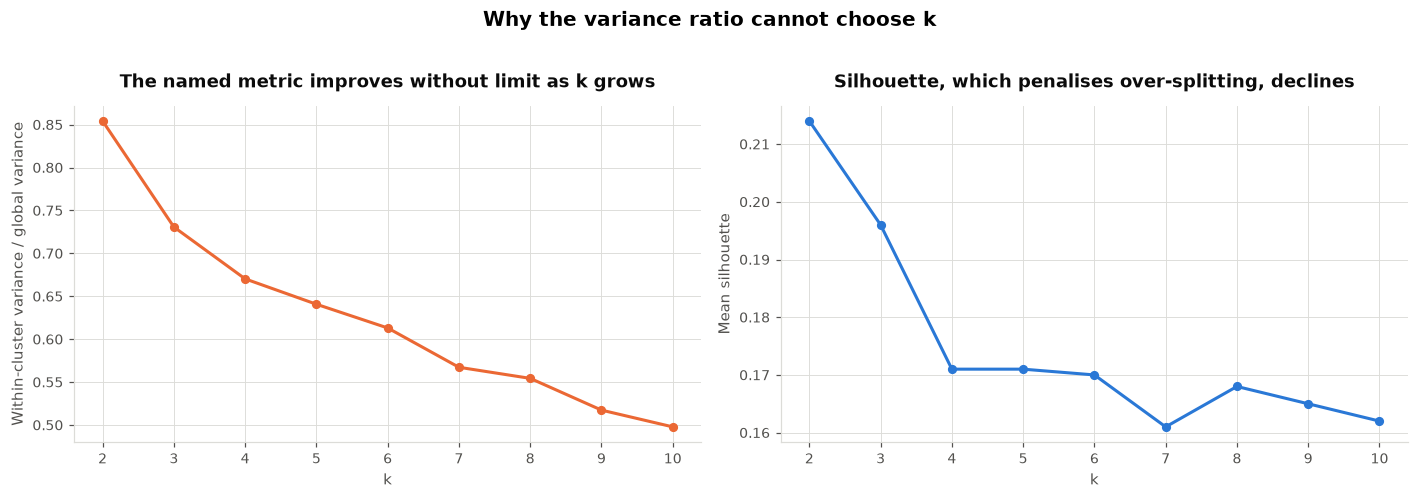

In [23]:
labellings = fit_all(scaled_matrix)
display(evaluate_partitions(scaled_matrix, labellings))

controls = {
    "K-Means (k=2)": kmeans_two,
    "K-Means (k=8, deliberately over-split)": KMeans(n_clusters=8, n_init=20, random_state=42).fit_predict(scaled_matrix),
    "Random labels (k=3)": np.random.default_rng(0).integers(0, 3, len(scaled_matrix)),
}
display(evaluate_partitions(scaled_matrix, controls))

ratio_by_k = pd.Series(
    {k: variance_ratio(scaled_matrix, KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(scaled_matrix))
     for k in range(2, 11)}
)
display(plot_metric_disagreement(kmeans_sweep, ratio_by_k))

**Results.**

| Partition | Variance ratio | Silhouette | Calinski-Harabasz | Davies-Bouldin |
|---|---|---|---|---|
| K-Means (k=3) | 0.731 | 0.196 | 350.3 | 1.722 |
| DBSCAN | 0.798 | 0.207 | 349.5 | 1.896 |
| Ward (k=3) | 0.745 | 0.158 | 291.7 | 1.912 |
| K-Means (k=2) | 0.854 | 0.214 | 363.0 | 1.855 |
| **K-Means (k=8)** | **0.554** | 0.168 | 227.4 | 1.649 |
| Random labels (k=3) | 0.998 | −0.006 | — | — |

**Interpretation — the metric is not suitable, and the table shows why.**

It does one thing correctly: random labels score **0.998**, essentially the
global variance, so the metric does detect that a meaningless partition is
meaningless. That is its floor, and it works.

But it **cannot compare partitions with different numbers of clusters**, which is
the main thing one wants a clustering metric to do. The ratio falls monotonically
as $k$ rises — 0.854 at $k=2$, 0.731 at $k=3$, 0.554 at $k=8$ — while silhouette
*declines* over the same range from 0.214 to 0.168. Taken at face value the
metric prefers $k=8$ to $k=2$, and it would prefer $k=100$ to $k=8$. In the limit
where every point is its own cluster the within-cluster variance is zero and the
ratio is perfect.

The reason is structural: **the metric is almost exactly what K-Means minimises.**
Total variance decomposes as within-cluster plus between-cluster variance, so
minimising the first is maximising the second, which is the K-Means objective.
Using it to evaluate clustering is therefore circular for K-Means, and it
structurally disadvantages DBSCAN, whose highest silhouette (0.207) comes with
the *worst* variance ratio (0.798) because DBSCAN is not trying to minimise that
quantity at all. It also has no natural definition for DBSCAN's noise label,
which must be excluded by hand.

**The alternative proposed is the silhouette coefficient.** For point $i$ with
mean distance $a(i)$ to its own cluster and $b(i)$ to the nearest other cluster,

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1].$$

It compares cohesion against separation, so splitting a homogeneous group in two
lowers it rather than raising it — it penalises over-splitting where the variance
ratio rewards it. It is defined per point, is comparable across different $k$ and
across methods with different objectives, and needs no assumption that clusters
are variance-minimising.

Its limitation must be stated too, and section 4.3 demonstrated it: silhouette
can be gamed by degenerate partitions, since the single-linkage split scored
0.337 with two singleton clusters. **No single internal metric is sufficient.**
This chapter therefore reports silhouette as the primary criterion, alongside
Calinski-Harabasz and Davies-Bouldin, cluster sizes, and the agreement between
methods — because a partition that only one algorithm can find is weak evidence
that it exists.

,K-Means (k=3),"DBSCAN (eps=1.8, min_samples=16)",Ward hierarchical (k=3)
K-Means (k=3),1.000,0.655,0.650
"DBSCAN (eps=1.8, min_samples=16)",0.655,1.000,0.481
Ward hierarchical (k=3),0.650,0.481,1.000


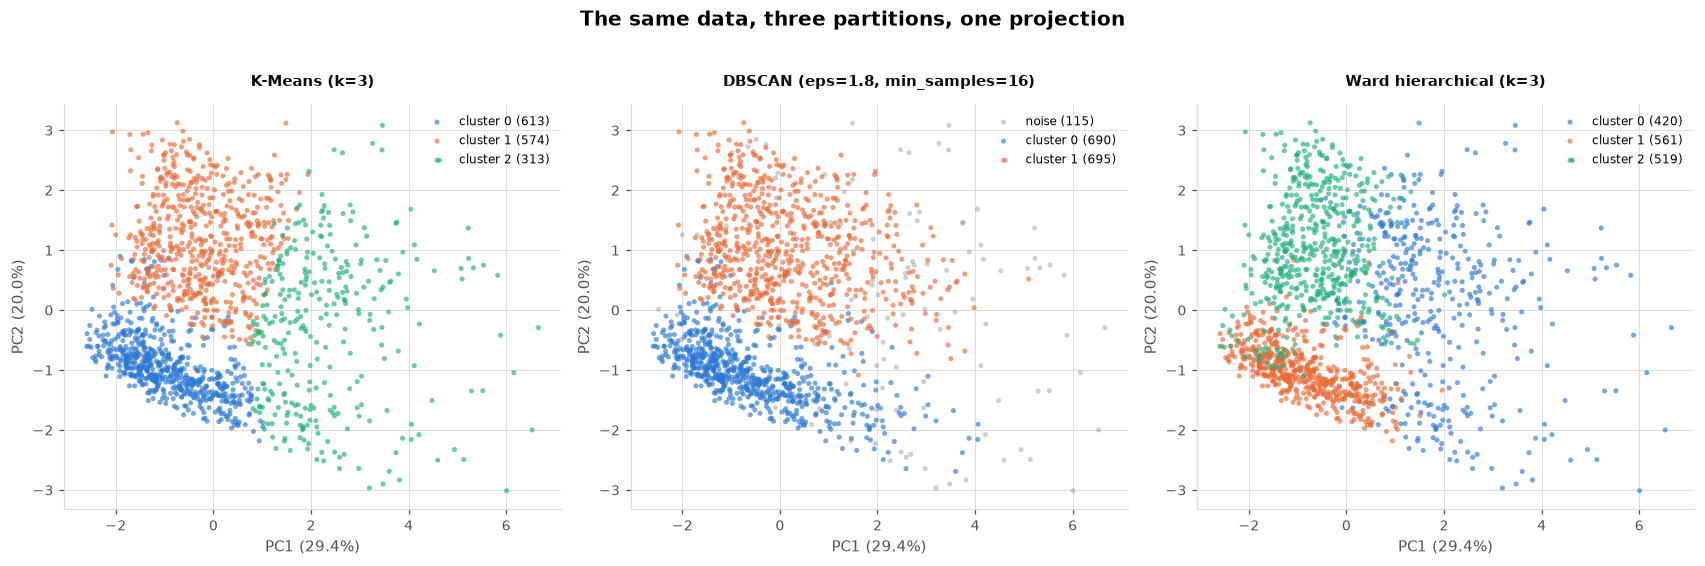

,Games,copiesSold,price,revenue,avgPlaytime,reviewScore,daysOnSale,publisherReleaseCount,selfPublished,Indie share,Median revenue
cluster,,,,,,,,,,,
0,613,-0.35,-0.37,-0.47,-0.21,-0.02,0.05,-0.58,1.02,0.995,62138.0
1,574,-0.38,0.00,-0.33,-0.24,-0.00,-0.07,0.57,-0.98,0.840,85000.0
2,313,1.39,0.71,1.54,0.85,0.04,0.04,0.08,-0.20,0.671,1756839.0


In [24]:
display(agreement_matrix(labellings))
display(plot_clusters_on_pca(scores, labellings, variance))
display(profile_clusters(scaled_matrix, labellings[f"K-Means (k={KMEANS_K})"], games))

### 4.5 Clusters on the PCA Projection, and Their Real-World Meaning

**Results.** Drawn on the same two components, the three partitions cut the same
undivided cloud in three different directions. No method's boundaries fall in a
gap, because there are no gaps. Agreement between methods is moderate at best:
ARI 0.650 between K-Means and Ward, 0.655 between K-Means and DBSCAN, and 0.481
between Ward and DBSCAN.

The K-Means profile shows what its clusters mean in the original variables.
Cluster 2 has the highest revenue, copies, price and playtime; cluster 0 the
lowest; cluster 1 sits between them and is distinguished mainly by publishing
structure.

**Interpretation — do the clusters have a meaningful real-world reading?**
**Partially, and less than they appear to.**

They *can* be described in domain terms: one group of small, cheap,
self-published titles with modest revenue; one group of larger, costlier titles
from established publishers; and an intermediate group. That description is
accurate — the profiles support it — and it is the kind of statement a
non-technical reader would find intuitive.

But it does not follow that these are *distinct kinds of game*. The same
description would be produced by cutting a single continuous gradient into three
parts at arbitrary points, and every piece of evidence in this chapter says that
is what is happening: no elbow, silhouette below 0.25 everywhere, no density gap,
a cophenetic correlation of 0.487, moderate inter-method agreement, and no
visible separation in the projection. The annotation in section 3.3 pointed the
same way — studio scale shifts a game along PC1 but does not place it in a
distinct region.

**The honest conclusion is that these clusters are useful as descriptive strata
and not as discovered categories.** Calling cluster 2 "the AAA segment" would be
defensible as shorthand and misleading as a claim about the data. The assignment
explicitly allows for this outcome, and it is what the evidence supports.

Cophenetic correlation of the feature dendrogram: 0.949
  (for comparison, the best sample dendrogram achieved 0.679)


,Composition
Groups,
2,"copiesSold, price, revenue, avgPlaytime, publisherReleaseCount, selfPublished | reviewScore, day..."
3,"copiesSold, price, revenue, avgPlaytime, publisherReleaseCount, selfPublished | reviewScore | da..."
4,"publisherReleaseCount, selfPublished | copiesSold, price, revenue, avgPlaytime | reviewScore | d..."


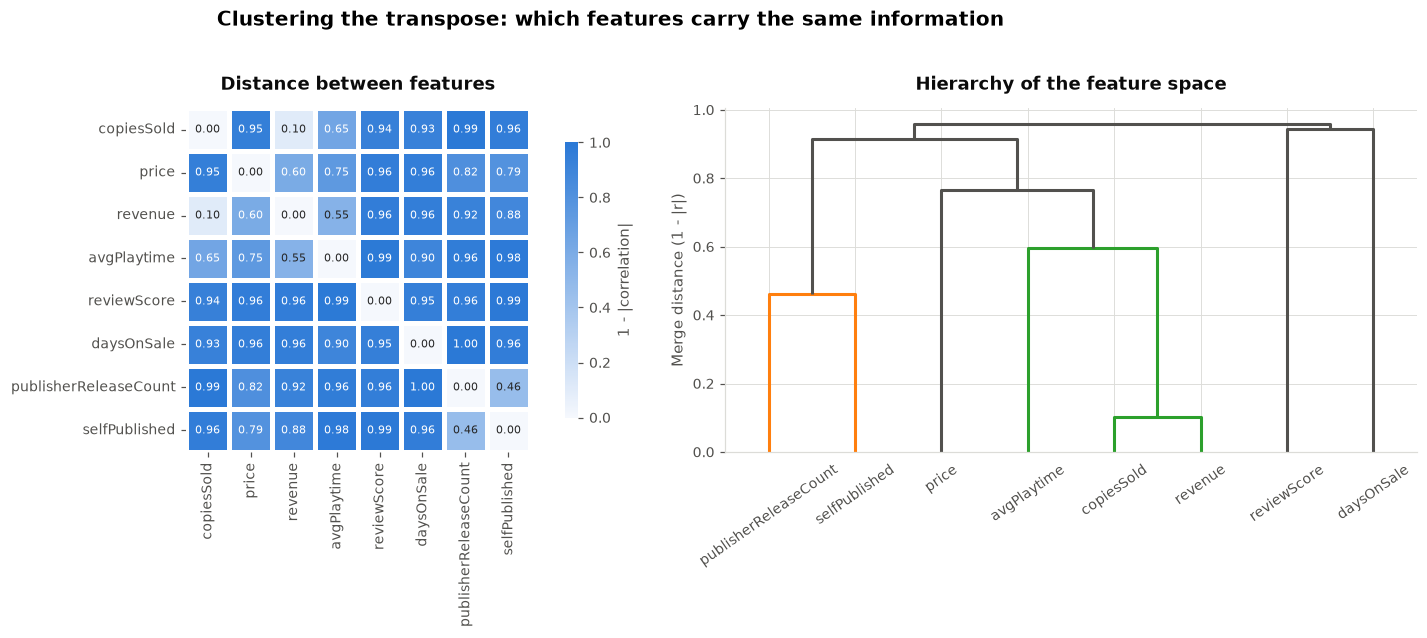

,Closest other feature,Distance to it,Mean distance to all others
reviewScore,copiesSold,0.94,0.962
daysOnSale,avgPlaytime,0.90,0.950
publisherReleaseCount,selfPublished,0.46,0.873
selfPublished,publisherReleaseCount,0.46,0.861
price,revenue,0.60,0.832
avgPlaytime,revenue,0.55,0.825
copiesSold,revenue,0.10,0.789
revenue,copiesSold,0.10,0.711


In [25]:
feature_distance = feature_distance_matrix(scaled_matrix)
feature_groups, feature_tree, cophenetic_r = cluster_features(feature_distance)

print(f"Cophenetic correlation of the feature dendrogram: {cophenetic_r:.3f}")
print("  (for comparison, the best sample dendrogram achieved 0.679)")
display(feature_groups)
display(plot_feature_space(feature_distance, feature_tree))
display(feature_isolation(feature_distance))

### 4.6 Clustering the Feature Space

**Method.** The assignment requires clustering the transpose of the data matrix —
grouping the eight *features* rather than the 1,500 games. This needs a notion of
distance between columns, and correlation distance $d(i,j)=1-|r_{ij}|$ is the
natural choice: two features are close when they carry the same information,
regardless of the sign of the relationship. Average linkage is used, since Ward's
variance criterion has no meaning on a correlation distance.

**Results.** The feature dendrogram has a cophenetic correlation of **0.949**,
against 0.487 for the best sample clustering by Ward. Cutting it into four groups
gives:

| Group | Features |
|---|---|
| Commercial scale | `copiesSold`, `revenue`, `price`, `avgPlaytime` |
| Publishing structure | `publisherReleaseCount`, `selfPublished` |
| Isolated | `reviewScore` |
| Isolated | `daysOnSale` |

**Interpretation — the five questions the assignment asks.**

**What information does clustering the features give?** A map of which variables
are substitutes for one another. `copiesSold` and `revenue` merge at a distance
of **0.10** — they are 90% redundant, and either could stand for the other in
almost any analysis. That single fact is more actionable for feature selection
than anything the sample clustering produced.

**Did it reveal related or redundant features?** Yes, two groups. The commercial
block is genuinely redundant at its core: the `copiesSold`–`revenue` pair is the
accounting identity established in chapter 1, with `price` and `avgPlaytime`
attaching more loosely at distances of 0.60 and 0.55. The publishing pair merges
at 0.46, reflecting that prolific publishers rarely publish their own games.

**Were any features isolated?** Two, clearly. **`reviewScore` has a mean distance
of 0.962 to all other features and `daysOnSale` 0.950** — both close to the
maximum of 1.0, meaning they share almost no information with anything else in
the matrix. `reviewScore` is the more striking: critical reception is essentially
orthogonal to every commercial and structural variable recorded here.

**Did it reveal anything the sample clustering did not?** Yes, and this is the
most useful contrast in the chapter. **The sample space has no reliable
hierarchy — cophenetic 0.487 — while the feature space has a very clean one at
0.949.** The 1,500 games do not fall into groups, but the eight variables
demonstrably do. Structure exists in this dataset; it lives in the relationships
between the columns, not in the arrangement of the rows.

It also independently reproduces the PCA result by a different route: the
commercial block corresponds to PC1, the publishing pair to PC2, and the two
isolated features to the PC3 subspace. Two methods with different objectives
recovering the same organisation is stronger evidence than either alone.

**Where is feature clustering useful?** Wherever features are numerous and
partly redundant: selecting one representative per group to reduce
dimensionality without a projection, which preserves interpretability in a way
PCA does not; detecting sensor duplication in IoT and industrial monitoring;
grouping co-expressed genes; and identifying multicollinearity before fitting a
regression. It is most valuable when $p$ is large enough that the correlation
matrix cannot simply be read.

**Conclusion for this section.** Clustering the feature space succeeded where
clustering the samples did not. It found a clean, stable hierarchy, quantified
the redundancy between `copiesSold` and `revenue`, and identified `reviewScore`
and `daysOnSale` as carrying independent information.

### 4.7 Discussion

**Why do different algorithms produce different clusters?** Because each
optimises a different objective, and when no strong structure exists the
objective is what determines the answer. K-Means minimises within-cluster
variance and therefore produces compact, roughly equal-sized groups; it cut the
commercial-scale axis. DBSCAN seeks density-connected regions and found the
binary gap in `selfPublished`. Ward minimises variance increase at each merge and
produced a third partition. The ARI values of 0.48 to 0.66 between them quantify
the disagreement, and the near-zero ARI of **0.087** between DBSCAN and K-Means
at $k=2$ shows how complete it can be. **On data with genuine separation these
methods would largely agree; the disagreement is the evidence that separation is
absent.**

**Sensitivity to hyperparameters.** DBSCAN is the extreme case: `eps` moving from
2.0 to 2.2 — a change of 10% — takes the result from two clusters covering 95% of
the data to one cluster covering 97%. K-Means is sensitive to $k$, which no
internal criterion here selects convincingly. Ward is sensitive to the cut height,
and the linkage comparison showed the rule itself matters more than the cut:
single and Ward linkage on identical data produced partitions of [1498, 1, 1] and
[420, 561, 519]. Separately from these tuning parameters, section 4.2 showed the
result also depends on the **feature-space representation** — including one
binary column changed what DBSCAN found entirely.

**Cluster geometry.** The methods assume different shapes: K-Means spherical and
isotropic, Ward compact and variance-minimising, DBSCAN arbitrary but of uniform
density. The observed geometry is a single elongated cloud, denser at low PC1 and
thinning towards high PC1 — the shape of a heavy-tailed distribution after a log
transform, not of separated groups. None of the three assumed shapes matches it,
which is why none produced a convincing partition.

**Density-based versus centroid-based.** The contrast is sharp here. The
centroid-based methods partitioned the continuum into slices; the density-based
method refused to, collapsing everything into one cluster as soon as `eps`
exceeded 2.1. DBSCAN's answer is arguably the more informative: it is capable of
reporting "one cluster and some noise", and that is close to what it reported.
K-Means has no way to express that conclusion, because it must return exactly
$k$ non-empty clusters whatever the data looks like.

**When can clustering fail?** This dataset illustrates three modes. It fails when
**no cluster structure exists** and the data is a single continuous population —
the situation here, where the algorithms still return partitions that look
plausible. It fails when **the representation dominates the geometry**, as the
binary feature did for DBSCAN. And it fails when **the evaluation metric is
aligned with one method's objective**, as the variance ratio is with K-Means,
so the comparison is decided before it begins.

**Conclusion.** The evidence points consistently in one direction. Silhouette
never exceeds 0.214 across any method or parameter setting; inertia shows no
elbow; DBSCAN finds no density gap and collapses to a single cluster at a
moderate radius; the sample dendrogram has a cophenetic correlation of 0.487; the
methods agree with each other only moderately; and the PCA projections show one
undivided cloud. **This dataset does not appear to contain distinct clusters of
games.** The partitions produced here are defensible as descriptive strata along
a commercial-scale gradient, and should not be presented as discovered
categories. The structure that does exist in this dataset is between its
features, not between its rows — and section 4.6 found it cleanly.

## 5. Multi-Dimensional Anomaly Detection

*Not yet written.* The main part of the assignment: the Z-score method, Isolation Forest and Local Outlier Factor, each with its assumptions, parameters and visualisation.

## 6. Comparison of Anomaly Detection Methods

*Not yet written.* Agreement and disagreement between the three methods, their sensitivity to scaling and dimensionality, runtime, robustness, interpretability, and what false positives and false negatives mean for this dataset in plain terms.

## 7. Critical Analysis and Reflection

*Not yet written.* Why anomaly detection is ill-defined, the curse of dimensionality, distance in high dimensions, noise versus genuine anomaly, the risks of assuming Gaussianity, and why post-projection visualisations can mislead.

## 8. Ethical Considerations

*Not yet written.* False alarms, surveillance, medical and cybersecurity applications, and the privacy, bias and fairness consequences of labelling behaviour as abnormal.

## 9. Final Visualization Dashboard (Optional)

*Not yet written.* Optional bonus. To be attempted only once every required section is complete.